In [84]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchinfo import summary
from torchvision import models
from sklearn.metrics import f1_score

from itertools import product

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)


Device: cuda


In [85]:
# Paths
DATA_DIR   = '/kaggle/input/tiny-imagenet/tiny-imagenet-200'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
VAL_DIR    = os.path.join(DATA_DIR, 'val')
WNIDS_FILE = os.path.join(DATA_DIR, 'wnids.txt')
WORDS_FILE = os.path.join(DATA_DIR, 'words.txt')

# Read all 200 wnids, pick first 20
with open(WNIDS_FILE) as f:
    all_wnids = [l.strip() for l in f]
selected_wnids = all_wnids[:20]
class2idx = {wnid:i for i,wnid in enumerate(selected_wnids)}

# Map wnid -> human label
wnid2name = {}
with open(WORDS_FILE) as f:
    for line in f:
        wnid, words = line.strip().split('\t')
        if wnid in selected_wnids:
            wnid2name[wnid] = words.split(',')[0]

print("Selected classes:")
for wnid in selected_wnids:
    print(f" {class2idx[wnid]:2d}: {wnid} → {wnid2name[wnid]}")


Selected classes:
  0: n02124075 → Egyptian cat
  1: n04067472 → reel
  2: n04540053 → volleyball
  3: n04099969 → rocking chair
  4: n07749582 → lemon
  5: n01641577 → bullfrog
  6: n02802426 → basketball
  7: n09246464 → cliff
  8: n07920052 → espresso
  9: n03970156 → plunger
 10: n03891332 → parking meter
 11: n02106662 → German shepherd
 12: n03201208 → dining table
 13: n02279972 → monarch
 14: n02132136 → brown bear
 15: n04146614 → school bus
 16: n07873807 → pizza
 17: n02364673 → guinea pig
 18: n04507155 → umbrella
 19: n03854065 → organ


In [ ]:
from PIL import Image

class TinyImageNet(Dataset):
    def __init__(self, root_dir, wnids, split='train', transform=None):
        self.transform = transform
        self.samples = []
        # TRAIN
        if split == 'train':
            for wnid in wnids:
                folder = os.path.join(root_dir, 'train', wnid, 'images')
                for fn in os.listdir(folder):
                    if fn.endswith('.JPEG'):
                        self.samples.append((os.path.join(folder, fn),
                                             class2idx[wnid]))
        # VAL
        else:
            annots = {}
            with open(os.path.join(root_dir, 'val', 'val_annotations.txt')) as f:
                for line in f:
                    img, wnid, *_ = line.strip().split('\t')
                    annots[img] = wnid
            folder = os.path.join(root_dir, 'val', 'images')
            for fn in os.listdir(folder):
                if not fn.endswith('.JPEG'): continue
                wnid = annots[fn]
                if wnid in wnids:
                    self.samples.append((os.path.join(folder, fn),
                                         class2idx[wnid]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')           
        if self.transform:
            img = self.transform(img)                    
        return img, label


In [ ]:
train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(64, padding=4),
    T.ToTensor(),
    T.Normalize(mean=[0.480,0.448,0.398],
                std =[0.277,0.269,0.282]),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.480,0.448,0.398],
                std =[0.277,0.269,0.282]),
])

train_ds = TinyImageNet(DATA_DIR, selected_wnids, split='train', transform=train_tf)
val_ds   = TinyImageNet(DATA_DIR, selected_wnids, split='val',   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False,
                          num_workers=4, pin_memory=True)


In [88]:
# 3) Baseline model: SmallCNN
class SmallCNN(nn.Module):
    def __init__(self, num_classes=20):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )
    def forward(self,x):
        return self.classifier(self.features(x))

model = SmallCNN().to(device)
print(model)


SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=20, bias=True)
  )
)


In [89]:
# 4) Helpers: train, evaluate, design-contribs
def train_one_epoch(model, loader, opt, crit):
    model.train()
    running_loss, correct, total = 0,0,0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out,y)
        loss.backward(); opt.step()
        running_loss += loss.item()*x.size(0)
        preds = out.argmax(1)
        correct += (preds==y).sum().item()
        total += y.size(0)
    return running_loss/total, correct/total

def eval_one_epoch(model, loader, crit):
    model.eval()
    running_loss, correct, total = 0,0,0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            running_loss += crit(out,y).item()*x.size(0)
            preds = out.argmax(1)
            correct += (preds==y).sum().item()
            total += y.size(0)
    return running_loss/total, correct/total

def compute_design_contributions(model):
    return {'#params': sum(p.numel() for p in model.parameters())}


In [ ]:
# 5) One-shot training & eval on baseline
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
for epoch in range(1,16):
    tl, ta = train_one_epoch(model, train_loader, optimizer, criterion)
    vl, va = eval_one_epoch(model, val_loader,   criterion)
    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);     history['val_acc'].append(va)
    print(f"Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val   L={vl:.4f} A={va:.4f}")


Epoch 1/15 — Train L=2.7862 A=0.1402 | Val   L=2.6529 A=0.2040
Epoch 2/15 — Train L=2.5078 A=0.2402 | Val   L=2.5022 A=0.2670
Epoch 3/15 — Train L=2.3661 A=0.2894 | Val   L=2.3680 A=0.2920
Epoch 4/15 — Train L=2.2640 A=0.3247 | Val   L=2.2872 A=0.2990
Epoch 5/15 — Train L=2.1647 A=0.3580 | Val   L=2.1837 A=0.3470
Epoch 6/15 — Train L=2.0834 A=0.3743 | Val   L=2.1092 A=0.3780
Epoch 7/15 — Train L=2.0172 A=0.3993 | Val   L=2.0758 A=0.3870
Epoch 8/15 — Train L=1.9754 A=0.4129 | Val   L=1.9920 A=0.4320
Epoch 9/15 — Train L=1.9134 A=0.4278 | Val   L=2.0069 A=0.4000
Epoch 10/15 — Train L=1.8685 A=0.4463 | Val   L=2.0610 A=0.4020
Epoch 11/15 — Train L=1.8483 A=0.4491 | Val   L=1.8821 A=0.4560
Epoch 12/15 — Train L=1.7989 A=0.4641 | Val   L=2.1296 A=0.3940
Epoch 13/15 — Train L=1.7821 A=0.4669 | Val   L=1.8650 A=0.4540
Epoch 14/15 — Train L=1.7481 A=0.4745 | Val   L=1.8538 A=0.4480
Epoch 15/15 — Train L=1.7168 A=0.4876 | Val   L=1.7978 A=0.4800


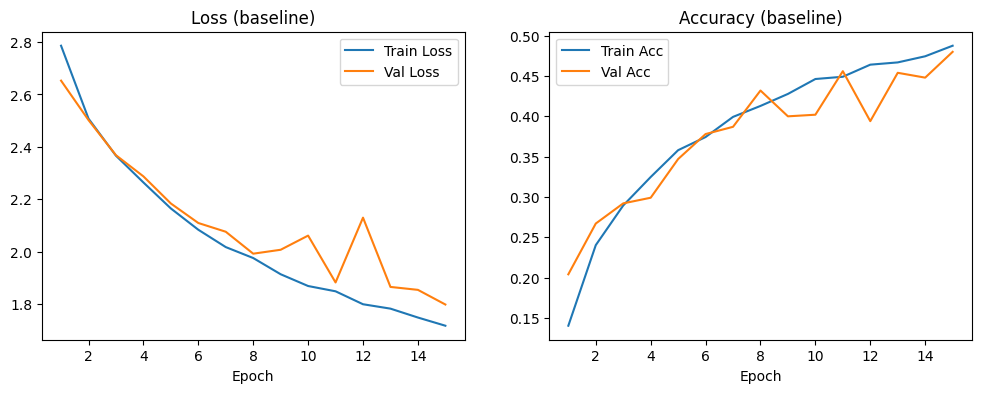

In [91]:
# 6) Train/validation loss & accuracy curves (dynamic)
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'],   label='Val Loss')
plt.title('Loss (baseline)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], label='Train Acc')
plt.plot(epochs, history['val_acc'],   label='Val Acc')
plt.title('Accuracy (baseline)'); plt.xlabel('Epoch'); plt.legend()

plt.show()


In [92]:
# 7) Initial metrics & design contributions
import pandas as pd
init_contribs = compute_design_contributions(model)
df_baseline = pd.DataFrame([{
    'model':'small_cnn',
    'stage':'initial',
    'val_acc':history['val_acc'][-1],
    'val_loss':history['val_loss'][-1],
    **init_contribs
}])
df_baseline


,model,stage,val_acc,val_loss,#params
0,small_cnn,initial,0.48,1.797845,95828


In [ ]:
# 8) Hyperparameter search (lr, batch_size, embedding_dim)
from itertools import product

param_grid = {
    'lr':[1e-4,1e-3,1e-2,],
    'batch_size':[32,64,128],
    'embedding_dim':[32,64,128]
}

search_records = []
for lr, bs, emb in product(param_grid['lr'], param_grid['batch_size'], param_grid['embedding_dim']):
    # rebuild model & loaders
    m = SmallCNN().to(device)
    tl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4)
    vl = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4)
    opt = optim.Adam(m.parameters(), lr=lr)
    # train 5 epochs
    hist = {'val_acc':[]}
    for _ in range(5):
        train_one_epoch(m, tl, opt, criterion)
        _,va = eval_one_epoch(m, vl, criterion)
        hist['val_acc'].append(va)
    search_records.append({'lr':lr,'batch_size':bs,'embedding_dim':emb,'val_acc':hist['val_acc'][-1]})

df_search = pd.DataFrame(search_records).sort_values('val_acc',ascending=False)
df_search.head()


,lr,batch_size,embedding_dim,val_acc
9,0.001,32,32,0.451
10,0.001,32,64,0.431
14,0.001,64,128,0.405
12,0.001,64,32,0.395
11,0.001,32,128,0.393


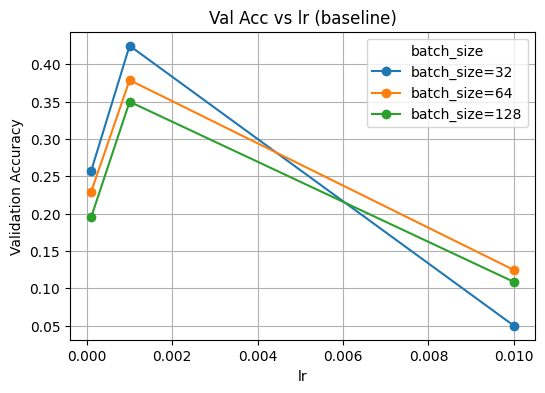

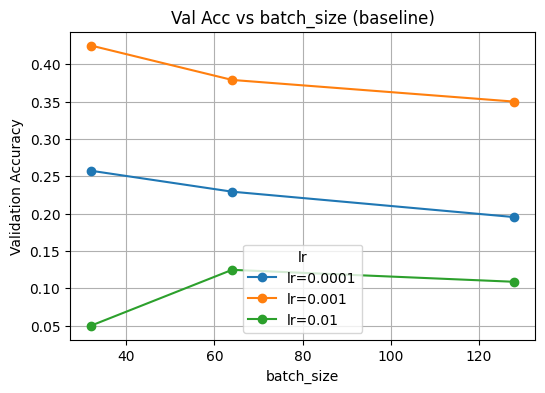

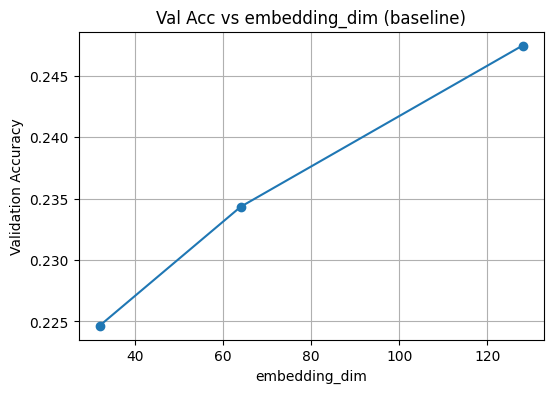

In [94]:
# 9) HP-effect plots (matplotlib only)
def plot_hp_effect(df, x, group=None):
    plt.figure(figsize=(6,4))
    if group is None:
        # average over any duplicates
        agg = df.groupby(x)['val_acc'].mean()
        plt.plot(agg.index, agg.values, marker='o')
    else:
        for gval, subset in df.groupby(group):
            agg = subset.groupby(x)['val_acc'].mean()
            plt.plot(agg.index, agg.values, marker='o', label=f"{group}={gval}")
        plt.legend(title=group)
    plt.xlabel(x)
    plt.ylabel('Validation Accuracy')
    plt.title(f'Val Acc vs {x} (baseline)')
    plt.grid(True)
    plt.show()

# examples:
plot_hp_effect(df_search, 'lr',         group='batch_size')
plot_hp_effect(df_search, 'batch_size', group='lr')
plot_hp_effect(df_search, 'embedding_dim')


In [96]:
# 10) Retrain on best configuration
best = df_search.iloc[0]
print("Best config:", best.to_dict())

model_best = SmallCNN().to(device)
train_loader = DataLoader(train_ds, batch_size=int(best.batch_size), shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=int(best.batch_size), shuffle=False, num_workers=4)
opt_best     = optim.Adam(model_best.parameters(), lr=float(best.lr))

history_best = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
for epoch in range(1,26):
    tl, ta = train_one_epoch(model_best, train_loader, opt_best, criterion)
    vl, va = eval_one_epoch(model_best, val_loader,   criterion)
    history_best['train_loss'].append(tl); history_best['train_acc'].append(ta)
    history_best['val_loss'].append(vl);   history_best['val_acc'].append(va)
    print(f"Epoch {epoch}/25 — Train L={tl:.4f} A={ta:.4f} | Val   L={vl:.4f} A={va:.4f}")


Best config: {'lr': 0.001, 'batch_size': 32.0, 'embedding_dim': 32.0, 'val_acc': 0.451}
Epoch 1/25 — Train L=2.6926 A=0.1780 | Val   L=2.5038 A=0.2500
Epoch 2/25 — Train L=2.3315 A=0.3020 | Val   L=2.3850 A=0.2920
Epoch 3/25 — Train L=2.1169 A=0.3606 | Val   L=2.1409 A=0.3790
Epoch 4/25 — Train L=1.9825 A=0.4037 | Val   L=2.0082 A=0.4110
Epoch 5/25 — Train L=1.8788 A=0.4374 | Val   L=1.9445 A=0.4240
Epoch 6/25 — Train L=1.8019 A=0.4604 | Val   L=1.9268 A=0.4280
Epoch 7/25 — Train L=1.7213 A=0.4833 | Val   L=1.8180 A=0.4460
Epoch 8/25 — Train L=1.6570 A=0.4980 | Val   L=1.7636 A=0.4650
Epoch 9/25 — Train L=1.5989 A=0.5162 | Val   L=1.6651 A=0.4980
Epoch 10/25 — Train L=1.5550 A=0.5325 | Val   L=1.6994 A=0.5050
Epoch 11/25 — Train L=1.5182 A=0.5366 | Val   L=1.6922 A=0.4880
Epoch 12/25 — Train L=1.4803 A=0.5561 | Val   L=1.5745 A=0.5400
Epoch 13/25 — Train L=1.4551 A=0.5559 | Val   L=1.6091 A=0.5240
Epoch 14/25 — Train L=1.4218 A=0.5660 | Val   L=1.5308 A=0.5430
Epoch 15/25 — Train L=1.3

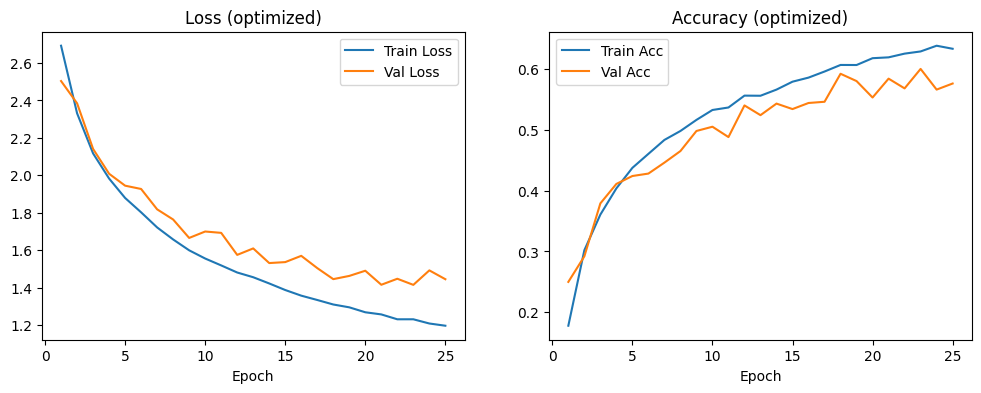

In [97]:
# 11) Optimized train/val curves (dynamic)
epochs = range(1, len(history_best['train_loss']) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history_best['train_loss'], label='Train Loss')
plt.plot(epochs, history_best['val_loss'],   label='Val Loss')
plt.title('Loss (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_best['train_acc'], label='Train Acc')
plt.plot(epochs, history_best['val_acc'],   label='Val Acc')
plt.title('Accuracy (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.show()


In [98]:
# 12) Final optimized metrics (using .loc)
best_contribs = compute_design_contributions(model_best)

# add a new row directly
df_baseline.loc[len(df_baseline)] = {
    'model': 'small_cnn',
    'stage': 'optimized',
    'val_acc': history_best['val_acc'][-1],
    'val_loss': history_best['val_loss'][-1],
    **best_contribs
}

df_baseline


,model,stage,val_acc,val_loss,#params
0,small_cnn,initial,0.480,1.797845,95828
1,small_cnn,optimized,0.576,1.444434,95828


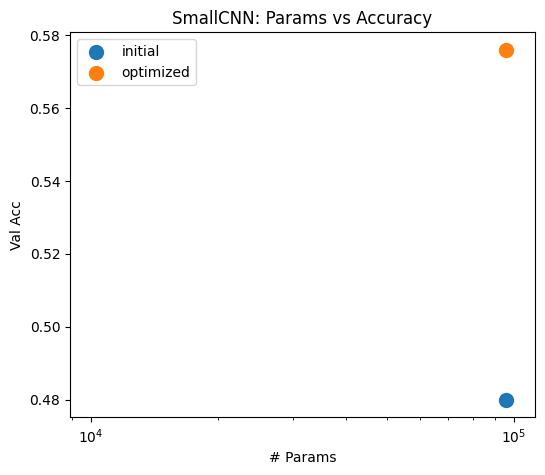

In [99]:
# 13) Combined trade-off scatter (so far only small_cnn)
plt.figure(figsize=(6,5))
for stage, grp in df_baseline.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=100, label=stage)
plt.xscale('log'); plt.xlabel('# Params'); plt.ylabel('Val Acc')
plt.title('SmallCNN: Params vs Accuracy'); plt.legend(); plt.show()


## medium cnn

In [100]:
# 3) Baseline model: MediumCNN
import torch.nn as nn

class MediumCNN(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=len(selected_classes)):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)), nn.Flatten()
        )
        self.embedding  = nn.Linear(256*4*4, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        return self.classifier(x)

model = MediumCNN(embedding_dim=128).to(device)
print(model)


MediumCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(4, 4))
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (embedding): Linear(in_features=4096, out_features=128, bias=True)
  (classifier): Linear(in_features=128, out_features=20, bias=True)
)


In [ ]:
# 4) One-shot training & eval on MediumCNN
optimizer = optim.Adam(model.parameters(), lr=1e-3)
history_med = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1,16):
    tl, ta = train_one_epoch(model, train_loader, optimizer, criterion)
    vl, va = eval_one_epoch(model, val_loader,   criterion)
    history_med['train_loss'].append(tl)
    history_med['train_acc'].append(ta)
    history_med['val_loss'].append(vl)
    history_med['val_acc'].append(va)
    print(f"[MediumCNN] Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


[MediumCNN] Epoch 1/15 — Train L=2.2171 A=0.3500 | Val L=1.9152 A=0.4360
[MediumCNN] Epoch 2/15 — Train L=1.7105 A=0.4840 | Val L=1.6699 A=0.4830
[MediumCNN] Epoch 3/15 — Train L=1.5374 A=0.5336 | Val L=1.7226 A=0.4950
[MediumCNN] Epoch 4/15 — Train L=1.4354 A=0.5664 | Val L=1.5554 A=0.5420
[MediumCNN] Epoch 5/15 — Train L=1.3548 A=0.5829 | Val L=1.4419 A=0.5770
[MediumCNN] Epoch 6/15 — Train L=1.3006 A=0.5995 | Val L=1.3454 A=0.5980
[MediumCNN] Epoch 7/15 — Train L=1.2335 A=0.6220 | Val L=1.3794 A=0.5940
[MediumCNN] Epoch 8/15 — Train L=1.1771 A=0.6366 | Val L=1.3034 A=0.6130
[MediumCNN] Epoch 9/15 — Train L=1.1339 A=0.6496 | Val L=1.3571 A=0.5950
[MediumCNN] Epoch 10/15 — Train L=1.0845 A=0.6655 | Val L=1.9464 A=0.4990
[MediumCNN] Epoch 11/15 — Train L=1.0483 A=0.6723 | Val L=1.3087 A=0.6300
[MediumCNN] Epoch 12/15 — Train L=0.9862 A=0.6897 | Val L=1.2848 A=0.6400
[MediumCNN] Epoch 13/15 — Train L=0.9466 A=0.7059 | Val L=1.3661 A=0.6220
[MediumCNN] Epoch 14/15 — Train L=0.9348 A=0.71

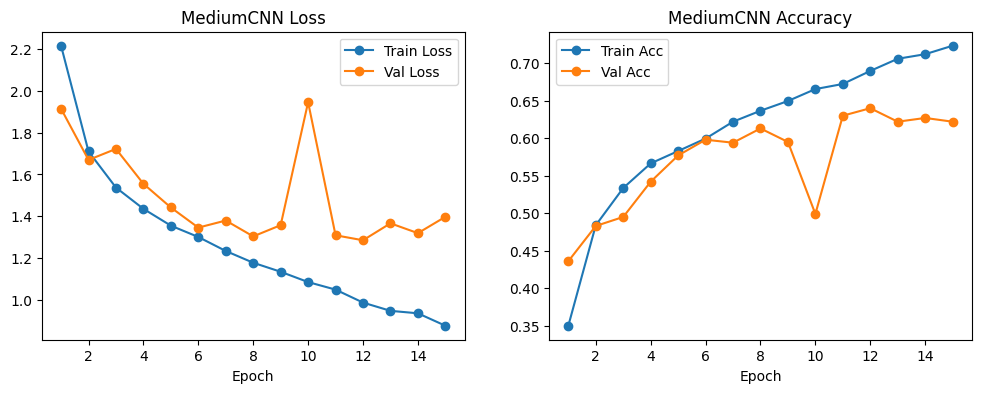

In [102]:
# 5) Loss & accuracy curves (dynamic)
eps = range(1, len(history_med['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(eps, history_med['train_loss'], marker='o', label='Train Loss')
plt.plot(eps, history_med['val_loss'],   marker='o', label='Val Loss')
plt.title('MediumCNN Loss'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(eps, history_med['train_acc'], marker='o', label='Train Acc')
plt.plot(eps, history_med['val_acc'],   marker='o', label='Val Acc')
plt.title('MediumCNN Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [103]:
# 6) Initial metrics & design contributions
init_contribs_med = compute_design_contributions(model)
df_medium = pd.DataFrame([{
    'model':       'medium_cnn',
    'stage':       'initial',
    'val_acc':     history_med['val_acc'][-1],
    'val_loss':    history_med['val_loss'][-1],
    **init_contribs_med
}])
df_medium


,model,stage,val_acc,val_loss,#params
0,medium_cnn,initial,0.622,1.397228,898708


In [104]:
# 7) Hyperparameter search (lr, batch_size, embedding_dim)
from itertools import product
search_med = []
for lr, bs, emb in product([1e-4,1e-3,1e-2], [64,128], [64,128]):
    m   = MediumCNN(embedding_dim=emb).to(device)
    tl  = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=4)
    vl  = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(5):
        train_one_epoch(m, tl, opt, criterion)
    _, va = eval_one_epoch(m, vl, criterion)
    search_med.append({
        'lr': lr,
        'batch_size': bs,
        'embedding_dim': emb,
        'val_acc': va
    })

df_search_med = pd.DataFrame(search_med).sort_values('val_acc', ascending=False)
df_search_med.head()


,lr,batch_size,embedding_dim,val_acc
4,0.0010,64,64,0.557
1,0.0001,64,128,0.556
6,0.0010,128,64,0.554
8,0.0100,64,64,0.554
9,0.0100,64,128,0.546


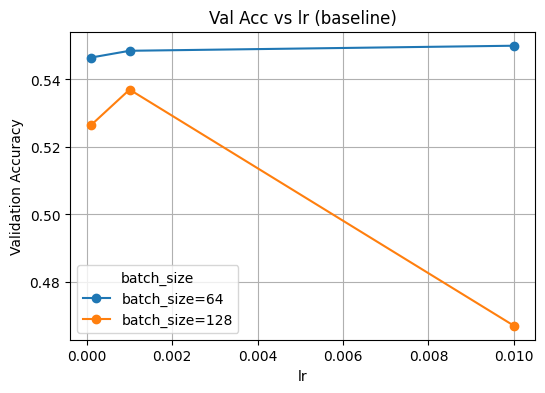

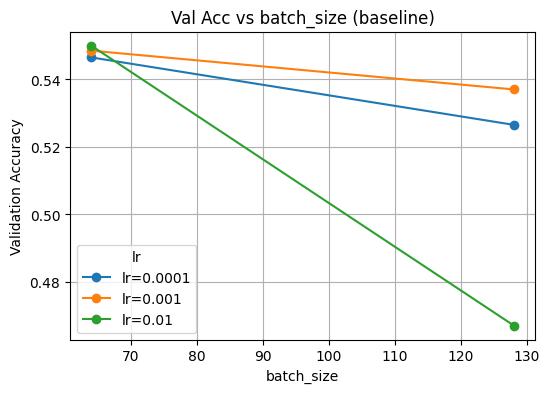

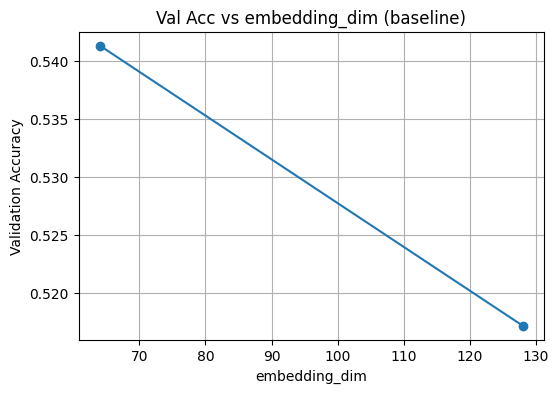

In [105]:
def plot_hp_effect(df, x, group=None):
    plt.figure(figsize=(6,4))
    if group is None:
        # average over any duplicates
        agg = df.groupby(x)['val_acc'].mean()
        plt.plot(agg.index, agg.values, marker='o')
    else:
        for gval, subset in df.groupby(group):
            agg = subset.groupby(x)['val_acc'].mean()
            plt.plot(agg.index, agg.values, marker='o', label=f"{group}={gval}")
        plt.legend(title=group)
    plt.xlabel(x)
    plt.ylabel('Validation Accuracy')
    plt.title(f'Val Acc vs {x} (baseline)')
    plt.grid(True)
    plt.show()
# 8) HP-effect plots (pure matplotlib)
plot_hp_effect(df_search_med, 'lr',         group='batch_size')
plot_hp_effect(df_search_med, 'batch_size', group='lr')
plot_hp_effect(df_search_med, 'embedding_dim')


In [106]:
# 9) Retrain on best MediumCNN config
best_med = df_search_med.iloc[0]
print("Best MediumCNN config:", best_med.to_dict())

model_med_best = MediumCNN(embedding_dim=int(best_med.embedding_dim)).to(device)
tlb = DataLoader(train_ds, batch_size=int(best_med.batch_size), shuffle=True,  num_workers=4)
vlb = DataLoader(val_ds,   batch_size=int(best_med.batch_size), shuffle=False, num_workers=4)
optb = optim.Adam(model_med_best.parameters(), lr=float(best_med.lr))

history_med_best = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for epoch in range(1,26):
    tl, ta = train_one_epoch(model_med_best, tlb, optb, criterion)
    vl, va = eval_one_epoch(model_med_best, vlb, criterion)
    history_med_best['train_loss'].append(tl)
    history_med_best['train_acc'].append(ta)
    history_med_best['val_loss'].append(vl)
    history_med_best['val_acc'].append(va)
    print(f"[MediumCNN Best] Epoch {epoch}/25 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


Best MediumCNN config: {'lr': 0.001, 'batch_size': 64.0, 'embedding_dim': 64.0, 'val_acc': 0.557}
[MediumCNN Best] Epoch 1/25 — Train L=2.1659 A=0.3610 | Val L=1.9924 A=0.4230
[MediumCNN Best] Epoch 2/25 — Train L=1.6571 A=0.5033 | Val L=1.7088 A=0.5050
[MediumCNN Best] Epoch 3/25 — Train L=1.4581 A=0.5562 | Val L=1.5591 A=0.5430
[MediumCNN Best] Epoch 4/25 — Train L=1.3662 A=0.5837 | Val L=1.5597 A=0.5370
[MediumCNN Best] Epoch 5/25 — Train L=1.2797 A=0.6058 | Val L=1.5051 A=0.5680
[MediumCNN Best] Epoch 6/25 — Train L=1.2232 A=0.6266 | Val L=1.3990 A=0.6010
[MediumCNN Best] Epoch 7/25 — Train L=1.1745 A=0.6422 | Val L=1.3621 A=0.5980
[MediumCNN Best] Epoch 8/25 — Train L=1.1202 A=0.6546 | Val L=1.4452 A=0.5810
[MediumCNN Best] Epoch 9/25 — Train L=1.0741 A=0.6700 | Val L=1.5560 A=0.5600
[MediumCNN Best] Epoch 10/25 — Train L=1.0569 A=0.6732 | Val L=1.2821 A=0.6210
[MediumCNN Best] Epoch 11/25 — Train L=0.9941 A=0.6933 | Val L=1.5457 A=0.5810
[MediumCNN Best] Epoch 12/25 — Train L=0.9

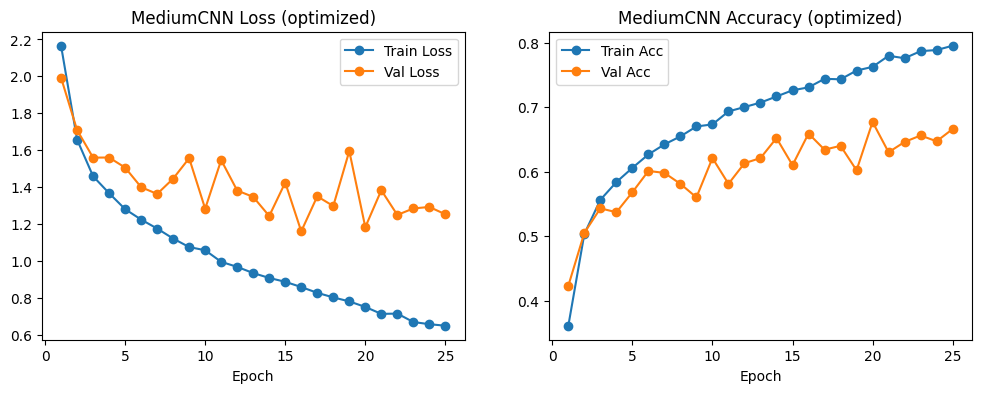

In [107]:
# 10) Optimized train/val curves for MediumCNN
epsb = range(1, len(history_med_best['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epsb, history_med_best['train_loss'], marker='o', label='Train Loss')
plt.plot(epsb, history_med_best['val_loss'],   marker='o', label='Val Loss')
plt.title('MediumCNN Loss (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epsb, history_med_best['train_acc'], marker='o', label='Train Acc')
plt.plot(epsb, history_med_best['val_acc'],   marker='o', label='Val Acc')
plt.title('MediumCNN Accuracy (optimized)'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [108]:
# 11) Final optimized metrics for MediumCNN
best_contribs_med = compute_design_contributions(model_med_best)
df_medium.loc[len(df_medium)] = {
    'model':    'medium_cnn',
    'stage':    'optimized',
    'val_acc':  history_med_best['val_acc'][-1],
    'val_loss': history_med_best['val_loss'][-1],
    **best_contribs_med
}
df_medium


,model,stage,val_acc,val_loss,#params
0,medium_cnn,initial,0.622,1.397228,898708
1,medium_cnn,optimized,0.666,1.251870,635220


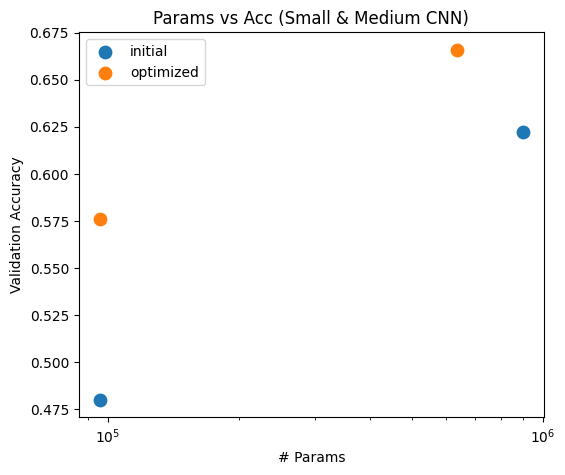

In [109]:
# 12) Combined trade-off scatter (SmallCNN + MediumCNN)
df_all = pd.concat([df_baseline, df_medium], ignore_index=True)
plt.figure(figsize=(6,5))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage)
plt.xscale('log'); plt.xlabel('# Params'); plt.ylabel('Validation Accuracy')
plt.title('Params vs Acc (Small & Medium CNN)'); plt.legend(); plt.show()


In [110]:
# 3) Baseline model: TargetCNN
import torch.nn as nn

class TargetCNN(nn.Module):
    def __init__(self, embedding_dim=256, num_classes=len(selected_classes)):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((2,2)),
            nn.Flatten()
        )
        self.embedding  = nn.Linear(256*2*2, embedding_dim)
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(embedding_dim, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        return self.classifier(x)

model_tgt = TargetCNN(embedding_dim=256).to(device)
print(model_tgt)


TargetCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), paddi

In [111]:
# 4) One-shot training & evaluation (15 epochs) on TargetCNN
optimizer = optim.Adam(model_tgt.parameters(), lr=1e-3)
history_tgt = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1,16):
    tl, ta = train_one_epoch(model_tgt, train_loader, optimizer, criterion)
    vl, va = eval_one_epoch(model_tgt,   val_loader,   criterion)
    history_tgt['train_loss'].append(tl)
    history_tgt['train_acc'].append(ta)
    history_tgt['val_loss'].append(vl)
    history_tgt['val_acc'].append(va)
    print(f"[TargetCNN] Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


[TargetCNN] Epoch 1/15 — Train L=2.5263 A=0.2280 | Val L=2.3024 A=0.3220
[TargetCNN] Epoch 2/15 — Train L=2.1573 A=0.3345 | Val L=2.0471 A=0.3820
[TargetCNN] Epoch 3/15 — Train L=1.9805 A=0.3930 | Val L=1.8870 A=0.4370
[TargetCNN] Epoch 4/15 — Train L=1.8352 A=0.4333 | Val L=1.7876 A=0.4600
[TargetCNN] Epoch 5/15 — Train L=1.7302 A=0.4701 | Val L=1.5715 A=0.5100
[TargetCNN] Epoch 6/15 — Train L=1.6433 A=0.4923 | Val L=1.6075 A=0.5150
[TargetCNN] Epoch 7/15 — Train L=1.5821 A=0.5148 | Val L=1.6140 A=0.5190
[TargetCNN] Epoch 8/15 — Train L=1.5217 A=0.5272 | Val L=1.3611 A=0.5880
[TargetCNN] Epoch 9/15 — Train L=1.4627 A=0.5508 | Val L=1.4816 A=0.5640
[TargetCNN] Epoch 10/15 — Train L=1.3945 A=0.5692 | Val L=1.8276 A=0.5020
[TargetCNN] Epoch 11/15 — Train L=1.3556 A=0.5784 | Val L=1.3267 A=0.5950
[TargetCNN] Epoch 12/15 — Train L=1.3123 A=0.5932 | Val L=1.3004 A=0.6020
[TargetCNN] Epoch 13/15 — Train L=1.2766 A=0.6014 | Val L=1.2973 A=0.5890
[TargetCNN] Epoch 14/15 — Train L=1.2483 A=0.61

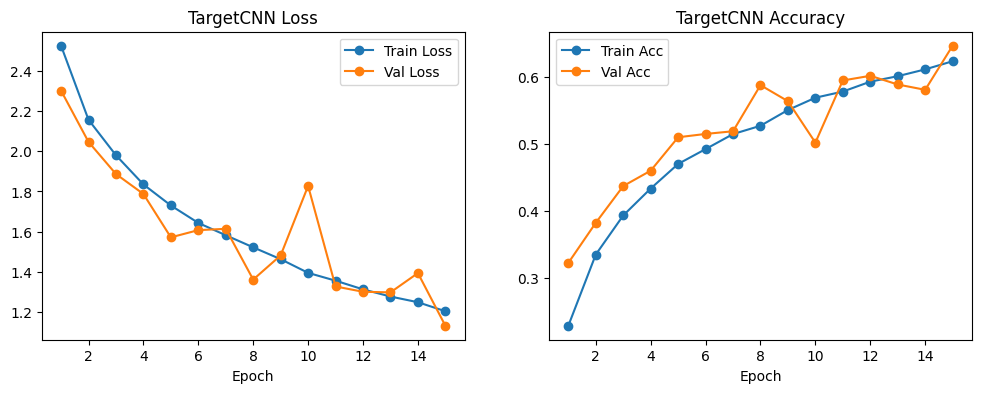

In [112]:
# 5) Train/val loss & accuracy curves (dynamic)
eps = range(1, len(history_tgt['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(eps, history_tgt['train_loss'], marker='o', label='Train Loss')
plt.plot(eps, history_tgt['val_loss'],   marker='o', label='Val Loss')
plt.title('TargetCNN Loss'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(eps, history_tgt['train_acc'], marker='o', label='Train Acc')
plt.plot(eps, history_tgt['val_acc'],   marker='o', label='Val Acc')
plt.title('TargetCNN Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [113]:
# 6) Initial metrics & design contributions
init_contribs_tgt = compute_design_contributions(model_tgt)
df_target = pd.DataFrame([{
    'model':    'target_cnn',
    'stage':    'initial',
    'val_acc':  history_tgt['val_acc'][-1],
    'val_loss': history_tgt['val_loss'][-1],
    **init_contribs_tgt
}])
df_target


,model,stage,val_acc,val_loss,#params
0,target_cnn,initial,0.647,1.131182,1414740


In [114]:
# 7) Hyperparameter search (lr, batch_size, embedding_dim)
from itertools import product
search_tgt = []
for lr, bs, emb in product([1e-4, 5e-4, 1e-3], [32, 64, 128], [32, 64]):
    m   = TargetCNN(embedding_dim=emb).to(device)
    tl  = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=4)
    vl  = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(3):
        train_one_epoch(m, tl, opt, criterion)
    _, va = eval_one_epoch(m, vl, criterion)
    search_tgt.append({
        'lr': lr,
        'batch_size': bs,
        'embedding_dim': emb,
        'val_acc': va
    })

df_search_tgt = pd.DataFrame(search_tgt).sort_values('val_acc', ascending=False)
df_search_tgt.head()


,lr,batch_size,embedding_dim,val_acc
1,0.0001,32,64,0.476
5,0.0001,128,64,0.455
3,0.0001,64,64,0.447
7,0.0005,32,64,0.443
2,0.0001,64,32,0.439


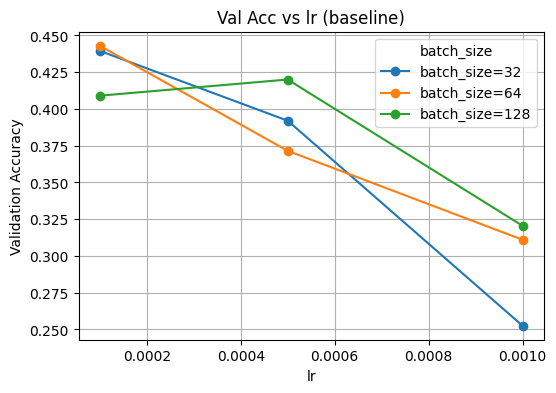

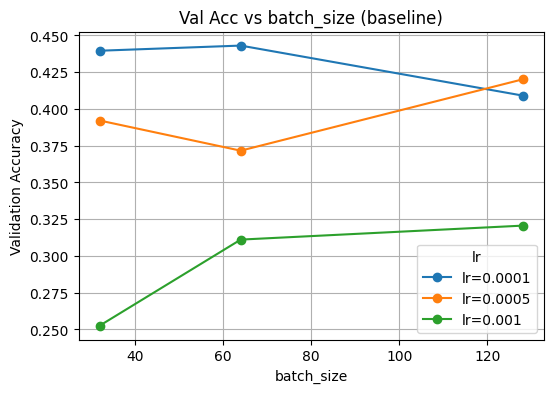

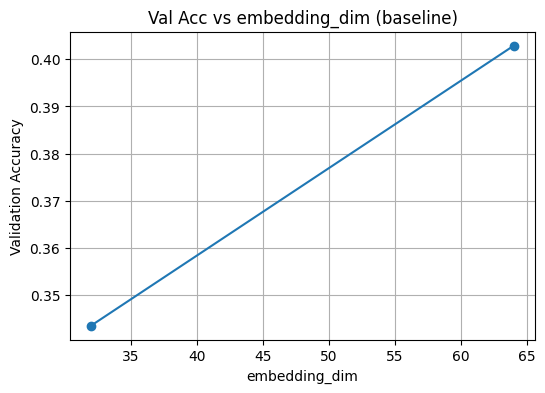

In [115]:
# 8) HP-effect plots (pure matplotlib)
plot_hp_effect(df_search_tgt, 'lr',         group='batch_size')
plot_hp_effect(df_search_tgt, 'batch_size', group='lr')
plot_hp_effect(df_search_tgt, 'embedding_dim')


In [116]:
# 9) Retrain on best TargetCNN configuration
best_tgt = df_search_tgt.iloc[0]
print("Best TargetCNN config:", best_tgt.to_dict())

model_tgt_best = TargetCNN(embedding_dim=int(best_tgt.embedding_dim)).to(device)
tlb = DataLoader(train_ds, batch_size=int(best_tgt.batch_size), shuffle=True,  num_workers=4)
vlb = DataLoader(val_ds,   batch_size=int(best_tgt.batch_size), shuffle=False, num_workers=4)
optb = optim.Adam(model_tgt_best.parameters(), lr=float(best_tgt.lr))

history_tgt_best = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for epoch in range(1,25):
    tl, ta = train_one_epoch(model_tgt_best, tlb, optb, criterion)
    vl, va = eval_one_epoch(model_tgt_best, vlb, criterion)
    history_tgt_best['train_loss'].append(tl)
    history_tgt_best['train_acc'].append(ta)
    history_tgt_best['val_loss'].append(vl)
    history_tgt_best['val_acc'].append(va)
    print(f"[TargetCNN Best] Epoch {epoch}/25 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


Best TargetCNN config: {'lr': 0.0001, 'batch_size': 32.0, 'embedding_dim': 64.0, 'val_acc': 0.476}
[TargetCNN Best] Epoch 1/25 — Train L=2.6455 A=0.2114 | Val L=2.2883 A=0.3410
[TargetCNN Best] Epoch 2/25 — Train L=2.2899 A=0.3231 | Val L=1.9569 A=0.4580
[TargetCNN Best] Epoch 3/25 — Train L=2.0518 A=0.3879 | Val L=1.7465 A=0.5040
[TargetCNN Best] Epoch 4/25 — Train L=1.8964 A=0.4268 | Val L=1.7105 A=0.4800
[TargetCNN Best] Epoch 5/25 — Train L=1.7764 A=0.4703 | Val L=1.5132 A=0.5340
[TargetCNN Best] Epoch 6/25 — Train L=1.6820 A=0.4966 | Val L=1.4842 A=0.5600
[TargetCNN Best] Epoch 7/25 — Train L=1.6065 A=0.5125 | Val L=1.4181 A=0.5660
[TargetCNN Best] Epoch 8/25 — Train L=1.5684 A=0.5248 | Val L=1.4563 A=0.5530
[TargetCNN Best] Epoch 9/25 — Train L=1.4990 A=0.5476 | Val L=1.4093 A=0.5760
[TargetCNN Best] Epoch 10/25 — Train L=1.4600 A=0.5578 | Val L=1.3149 A=0.5940
[TargetCNN Best] Epoch 11/25 — Train L=1.4193 A=0.5701 | Val L=1.4104 A=0.5570
[TargetCNN Best] Epoch 12/25 — Train L=1.

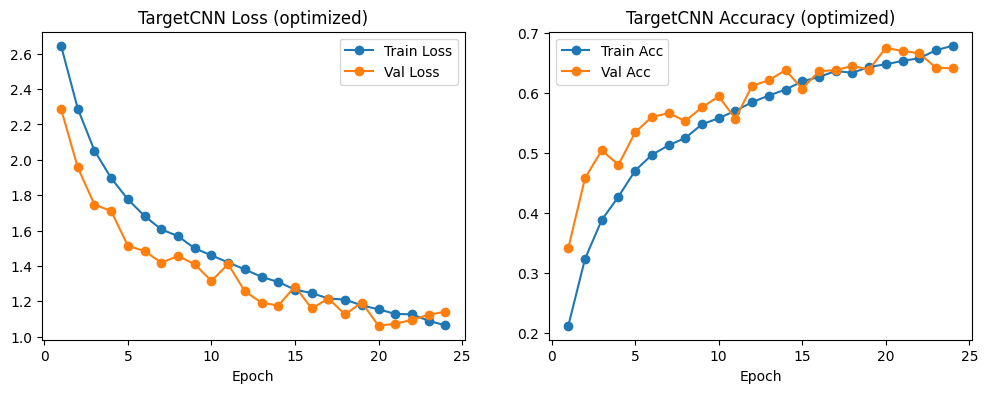

In [117]:
# 10) Optimized train/val curves (TargetCNN)
epsb = range(1, len(history_tgt_best['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epsb, history_tgt_best['train_loss'], marker='o', label='Train Loss')
plt.plot(epsb, history_tgt_best['val_loss'],   marker='o', label='Val Loss')
plt.title('TargetCNN Loss (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epsb, history_tgt_best['train_acc'], marker='o', label='Train Acc')
plt.plot(epsb, history_tgt_best['val_acc'],   marker='o', label='Val Acc')
plt.title('TargetCNN Accuracy (optimized)'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [118]:
# 11) Final optimized metrics for TargetCNN
best_contribs_tgt = compute_design_contributions(model_tgt_best)
df_target.loc[len(df_target)] = {
    'model':    'target_cnn',
    'stage':    'optimized',
    'val_acc':  history_tgt_best['val_acc'][-1],
    'val_loss': history_tgt_best['val_loss'][-1],
    **best_contribs_tgt
}
df_target


,model,stage,val_acc,val_loss,#params
0,target_cnn,initial,0.647,1.131182,1414740
1,target_cnn,optimized,0.641,1.140853,1214100


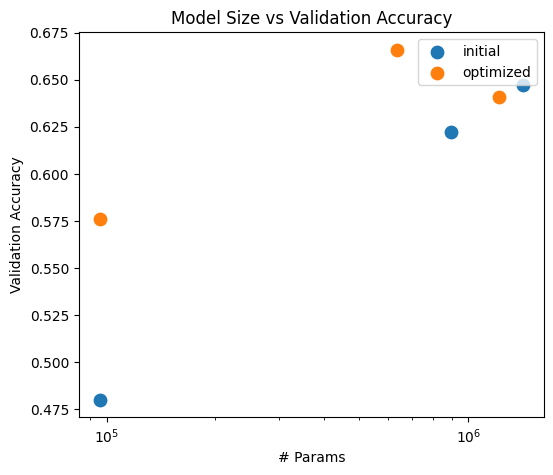

In [119]:
# 12) Combined trade-off scatter (Small, Medium, Target)
df_all = pd.concat([df_baseline, df_medium, df_target], ignore_index=True)
plt.figure(figsize=(6,5))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage)
plt.xscale('log'); plt.xlabel('# Params'); plt.ylabel('Validation Accuracy')
plt.title('Model Size vs Validation Accuracy'); plt.legend(); plt.show()


# Resnet18

In [120]:
# 3) Baseline model: ResNet18 with embedding head
from torchvision.models import resnet18
import torch.nn as nn

class ResNet18Emb(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=len(selected_classes)):
        super().__init__()
        backbone = resnet18(pretrained=False)
        in_feats = backbone.fc.in_features
        backbone.fc = nn.Identity()                      # remove original classifier
        self.backbone   = backbone
        self.embedding  = nn.Linear(in_feats, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)
    def forward(self, x):
        x = self.backbone(x)
        x = self.embedding(x)
        return self.classifier(x)

model_res = ResNet18Emb(embedding_dim=128).to(device)
print(model_res)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet18Emb(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
# 4) One-shot training & evaluation on ResNet18
optimizer = optim.Adam(model_res.parameters(), lr=1e-3)
history_res = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1,16):
    tl, ta = train_one_epoch(model_res, train_loader, optimizer, criterion)
    vl, va = eval_one_epoch(model_res,   val_loader,   criterion)
    history_res['train_loss'].append(tl)
    history_res['train_acc'].append(ta)
    history_res['val_loss'].append(vl)
    history_res['val_acc'].append(va)
    print(f"[ResNet18] Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


[ResNet18] Epoch 1/15 — Train L=2.5226 A=0.2329 | Val L=2.3908 A=0.2690
[ResNet18] Epoch 2/15 — Train L=2.0992 A=0.3621 | Val L=2.0388 A=0.3970
[ResNet18] Epoch 3/15 — Train L=1.8459 A=0.4417 | Val L=1.8989 A=0.4390
[ResNet18] Epoch 4/15 — Train L=1.6711 A=0.4877 | Val L=1.7067 A=0.4730
[ResNet18] Epoch 5/15 — Train L=1.5297 A=0.5327 | Val L=1.5661 A=0.5210
[ResNet18] Epoch 6/15 — Train L=1.4138 A=0.5587 | Val L=1.4641 A=0.5440
[ResNet18] Epoch 7/15 — Train L=1.3230 A=0.5894 | Val L=1.4594 A=0.5540
[ResNet18] Epoch 8/15 — Train L=1.2558 A=0.6138 | Val L=1.4033 A=0.5570
[ResNet18] Epoch 9/15 — Train L=1.1802 A=0.6380 | Val L=1.3246 A=0.6040
[ResNet18] Epoch 10/15 — Train L=1.1232 A=0.6538 | Val L=1.3703 A=0.5990
[ResNet18] Epoch 11/15 — Train L=1.0281 A=0.6780 | Val L=1.3685 A=0.6130
[ResNet18] Epoch 12/15 — Train L=0.9714 A=0.6981 | Val L=1.3194 A=0.6150
[ResNet18] Epoch 13/15 — Train L=0.9155 A=0.7138 | Val L=1.2641 A=0.6280
[ResNet18] Epoch 14/15 — Train L=0.8367 A=0.7365 | Val L=1.2

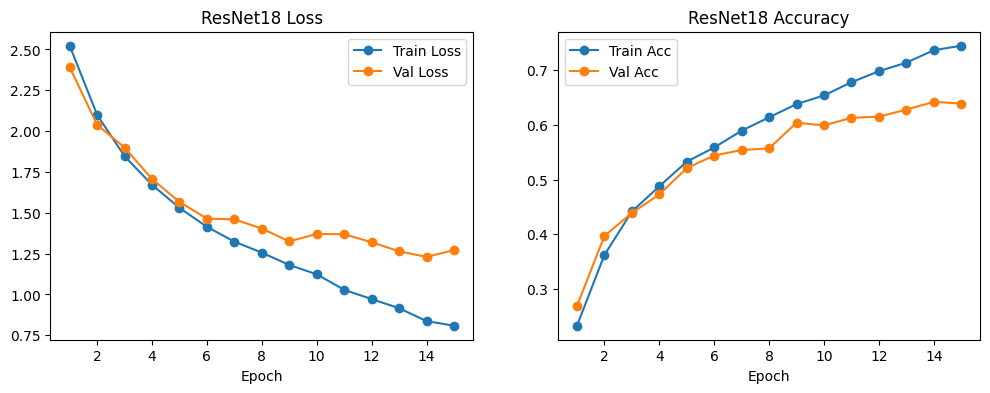

In [122]:
# 5) Train/val loss & accuracy curves (dynamic)
eps = range(1, len(history_res['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(eps, history_res['train_loss'], marker='o', label='Train Loss')
plt.plot(eps, history_res['val_loss'],   marker='o', label='Val Loss')
plt.title('ResNet18 Loss'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(eps, history_res['train_acc'], marker='o', label='Train Acc')
plt.plot(eps, history_res['val_acc'],   marker='o', label='Val Acc')
plt.title('ResNet18 Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [123]:
# 6) Initial metrics & design contributions
init_contribs_res = compute_design_contributions(model_res)
df_res = pd.DataFrame([{
    'model':    'resnet18',
    'stage':    'initial',
    'val_acc':  history_res['val_acc'][-1],
    'val_loss': history_res['val_loss'][-1],
    **init_contribs_res
}])
df_res


,model,stage,val_acc,val_loss,#params
0,resnet18,initial,0.639,1.271297,11244756


In [124]:
# 6) Initial metrics & design contributions
init_contribs_res = compute_design_contributions(model_res)
df_res = pd.DataFrame([{
    'model':    'resnet18',
    'stage':    'initial',
    'val_acc':  history_res['val_acc'][-1],
    'val_loss': history_res['val_loss'][-1],
    **init_contribs_res
}])
df_res


,model,stage,val_acc,val_loss,#params
0,resnet18,initial,0.639,1.271297,11244756


In [125]:
# 7) Hyperparameter search (lr, batch_size, embedding_dim)
from itertools import product
search_res = []
for lr, bs, emb in product([1e-4, 5e-4, 1e-3], [32, 64, 128], [32, 64,128]):
    m   = ResNet18Emb(embedding_dim=emb).to(device)
    tl  = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=4)
    vl  = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(5):
        train_one_epoch(m, tl, opt, criterion)
    _, va = eval_one_epoch(m, vl, criterion)
    search_res.append({
        'lr':lr, 'batch_size':bs, 'embedding_dim':emb, 'val_acc':va
    })

df_search_res = pd.DataFrame(search_res).sort_values('val_acc', ascending=False)
df_search_res.head()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


,lr,batch_size,embedding_dim,val_acc
12,0.0005,64,32,0.567
14,0.0005,64,128,0.551
24,0.0010,128,32,0.548
22,0.0010,64,64,0.542
9,0.0005,32,32,0.542


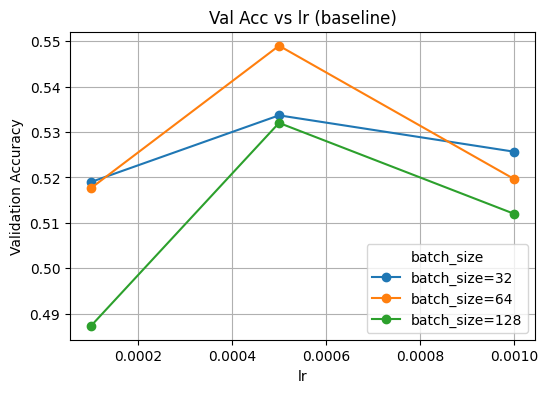

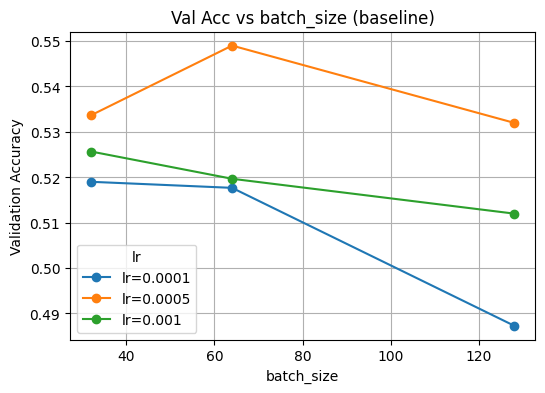

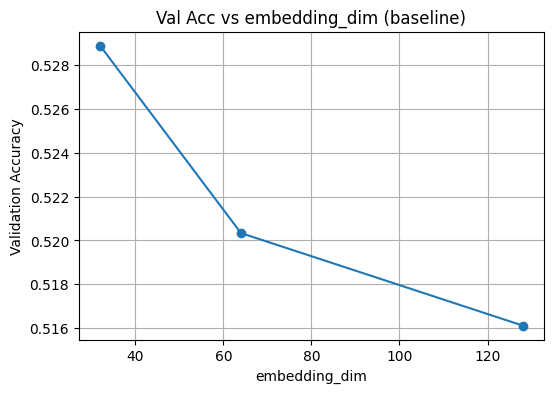

In [126]:
# 8) HP-effect plots (matplotlib only)
plot_hp_effect(df_search_res, 'lr',         group='batch_size')
plot_hp_effect(df_search_res, 'batch_size', group='lr')
plot_hp_effect(df_search_res, 'embedding_dim')


In [127]:
# 9) Retrain on best ResNet18 config
best_res = df_search_res.iloc[0]
print("Best ResNet18 config:", best_res.to_dict())

model_res_best = ResNet18Emb(embedding_dim=int(best_res.embedding_dim)).to(device)
tlb = DataLoader(train_ds, batch_size=int(best_res.batch_size), shuffle=True,  num_workers=4)
vlb = DataLoader(val_ds,   batch_size=int(best_res.batch_size), shuffle=False, num_workers=4)
optb = optim.Adam(model_res_best.parameters(), lr=float(best_res.lr))

history_res_best = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for epoch in range(1,16):
    tl, ta = train_one_epoch(model_res_best, tlb, optb, criterion)
    vl, va = eval_one_epoch(model_res_best, vlb, criterion)
    history_res_best['train_loss'].append(tl)
    history_res_best['train_acc'].append(ta)
    history_res_best['val_loss'].append(vl)
    history_res_best['val_acc'].append(va)
    print(f"[ResNet18 Best] Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


Best ResNet18 config: {'lr': 0.0005, 'batch_size': 64.0, 'embedding_dim': 32.0, 'val_acc': 0.567}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[ResNet18 Best] Epoch 1/15 — Train L=2.3827 A=0.2786 | Val L=2.2375 A=0.3290
[ResNet18 Best] Epoch 2/15 — Train L=1.8782 A=0.4299 | Val L=1.9292 A=0.4270
[ResNet18 Best] Epoch 3/15 — Train L=1.6322 A=0.5064 | Val L=1.8581 A=0.4580
[ResNet18 Best] Epoch 4/15 — Train L=1.4870 A=0.5442 | Val L=1.8017 A=0.4650
[ResNet18 Best] Epoch 5/15 — Train L=1.3893 A=0.5714 | Val L=1.5472 A=0.5370
[ResNet18 Best] Epoch 6/15 — Train L=1.2679 A=0.6075 | Val L=1.5246 A=0.5410
[ResNet18 Best] Epoch 7/15 — Train L=1.1837 A=0.6350 | Val L=1.5423 A=0.5500
[ResNet18 Best] Epoch 8/15 — Train L=1.0973 A=0.6567 | Val L=1.3574 A=0.5990
[ResNet18 Best] Epoch 9/15 — Train L=1.0346 A=0.6744 | Val L=1.3555 A=0.5930
[ResNet18 Best] Epoch 10/15 — Train L=0.9554 A=0.6992 | Val L=1.4399 A=0.5720
[ResNet18 Best] Epoch 11/15 — Train L=0.8998 A=0.7166 | Val L=1.3971 A=0.6120
[ResNet18 Best] Epoch 12/15 — Train L=0.8334 A=0.7349 | Val L=1.3697 A=0.6100
[ResNet18 Best] Epoch 13/15 — Train L=0.7810 A=0.7532 | Val L=1.3782 A=0.

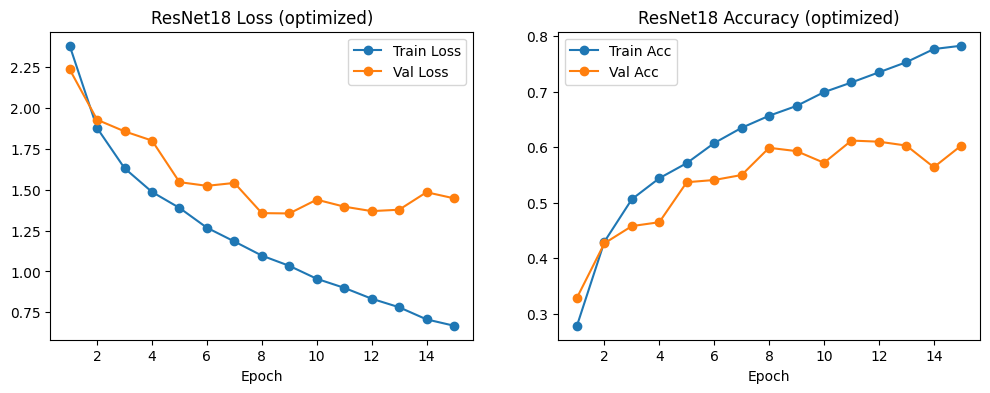

In [128]:
# 10) Optimized train/val curves (ResNet18)
epsb = range(1, len(history_res_best['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epsb, history_res_best['train_loss'], marker='o', label='Train Loss')
plt.plot(epsb, history_res_best['val_loss'],   marker='o', label='Val Loss')
plt.title('ResNet18 Loss (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epsb, history_res_best['train_acc'], marker='o', label='Train Acc')
plt.plot(epsb, history_res_best['val_acc'],   marker='o', label='Val Acc')
plt.title('ResNet18 Accuracy (optimized)'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [129]:
# 11) Final optimized metrics for ResNet18
best_contribs_res = compute_design_contributions(model_res_best)
df_res.loc[len(df_res)] = {
    'model':    'resnet18',
    'stage':    'optimized',
    'val_acc':  history_res_best['val_acc'][-1],
    'val_loss': history_res_best['val_loss'][-1],
    **best_contribs_res
}
df_res


,model,stage,val_acc,val_loss,#params
0,resnet18,initial,0.639,1.271297,11244756
1,resnet18,optimized,0.603,1.448145,11193588


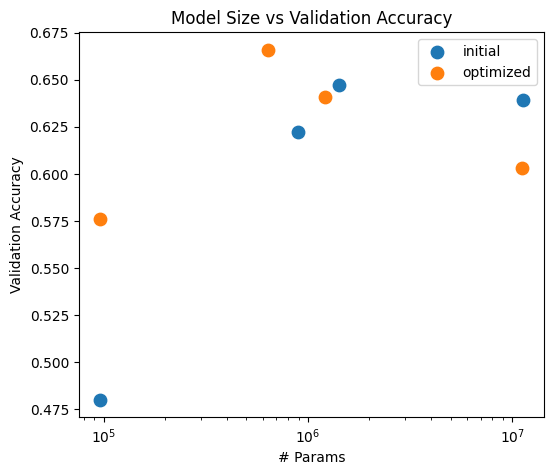

In [130]:
# 12) Combined trade-off scatter (Small, Medium, Target, ResNet18)
df_all = pd.concat([df_baseline, df_medium, df_target, df_res], ignore_index=True)
plt.figure(figsize=(6,5))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage)
plt.xscale('log'); plt.xlabel('# Params'); plt.ylabel('Validation Accuracy')
plt.title('Model Size vs Validation Accuracy'); plt.legend(); plt.show()


In [133]:
# 3) Baseline model: MobileNetV2
from torchvision.models import mobilenet_v2
import torch.nn as nn

class MobileNetV2Emb(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=len(selected_classes)):
        super().__init__()
        backbone = mobilenet_v2(pretrained=False)
        in_feats = backbone.last_channel
        backbone.classifier = nn.Identity()       # drop original head
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.flatten    = nn.Flatten()
        self.embedding  = nn.Linear(in_feats, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.embedding(x)
        return self.classifier(x)

model_mnet = MobileNetV2Emb(embedding_dim=128).to(device)
print(model_mnet)


MobileNetV2Emb(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, e

In [ ]:
# 4) One-shot training & evaluation on MobileNetV2
optimizer = optim.Adam(model_mnet.parameters(), lr=1e-3)
history_mnet = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1,16):
    tl, ta = train_one_epoch(model_mnet, train_loader, optimizer, criterion)
    vl, va = eval_one_epoch(model_mnet,   val_loader,   criterion)
    history_mnet['train_loss'].append(tl)
    history_mnet['train_acc'].append(ta)
    history_mnet['val_loss'].append(vl)
    history_mnet['val_acc'].append(va)
    print(f"[MobileNetV2] Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


[MobileNetV2] Epoch 1/15 — Train L=2.7526 A=0.1575 | Val L=2.5238 A=0.2440
[MobileNetV2] Epoch 2/15 — Train L=2.4379 A=0.2513 | Val L=2.3061 A=0.3070
[MobileNetV2] Epoch 3/15 — Train L=2.2502 A=0.3085 | Val L=2.1881 A=0.3280
[MobileNetV2] Epoch 4/15 — Train L=2.1256 A=0.3480 | Val L=2.0645 A=0.3680
[MobileNetV2] Epoch 5/15 — Train L=2.0176 A=0.3799 | Val L=1.9220 A=0.4070
[MobileNetV2] Epoch 6/15 — Train L=1.9294 A=0.4041 | Val L=1.9394 A=0.4060
[MobileNetV2] Epoch 7/15 — Train L=1.8466 A=0.4344 | Val L=1.8312 A=0.4440
[MobileNetV2] Epoch 8/15 — Train L=1.7717 A=0.4526 | Val L=1.7667 A=0.4560
[MobileNetV2] Epoch 9/15 — Train L=1.7142 A=0.4690 | Val L=1.6446 A=0.4870
[MobileNetV2] Epoch 10/15 — Train L=1.6424 A=0.4951 | Val L=1.6614 A=0.4810
[MobileNetV2] Epoch 11/15 — Train L=1.5963 A=0.5109 | Val L=1.6524 A=0.5060
[MobileNetV2] Epoch 12/15 — Train L=1.5412 A=0.5243 | Val L=1.5230 A=0.5430
[MobileNetV2] Epoch 13/15 — Train L=1.4990 A=0.5374 | Val L=1.5322 A=0.5500
[MobileNetV2] Epoch 1

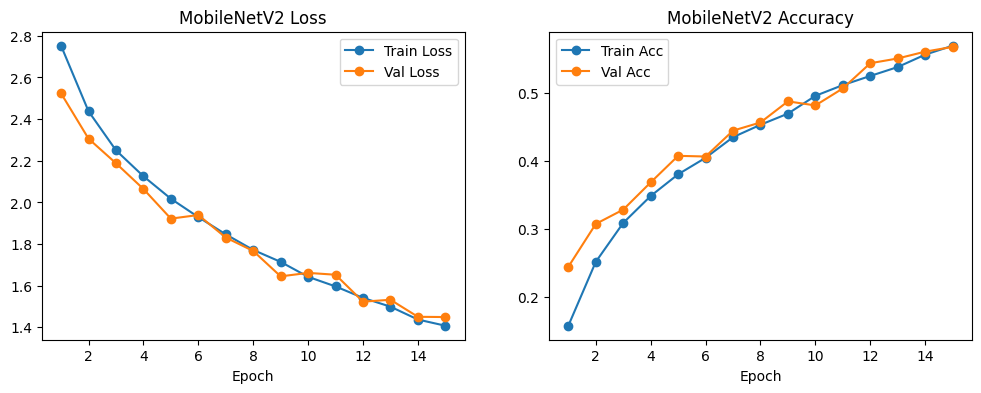

In [136]:
# 5) Train/validation loss & accuracy curves (dynamic)
eps = range(1, len(history_mnet['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(eps, history_mnet['train_loss'], marker='o', label='Train Loss')
plt.plot(eps, history_mnet['val_loss'],   marker='o', label='Val Loss')
plt.title('MobileNetV2 Loss'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(eps, history_mnet['train_acc'], marker='o', label='Train Acc')
plt.plot(eps, history_mnet['val_acc'],   marker='o', label='Val Acc')
plt.title('MobileNetV2 Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [137]:
# 6) Initial metrics & design contributions
init_contribs_mnet = compute_design_contributions(model_mnet)
df_mnet = pd.DataFrame([{
    'model':    'mobilenet_v2',
    'stage':    'initial',
    'val_acc':  history_mnet['val_acc'][-1],
    'val_loss': history_mnet['val_loss'][-1],
    **init_contribs_mnet
}])
df_mnet


,model,stage,val_acc,val_loss,#params
0,mobilenet_v2,initial,0.567,1.44919,2390420


In [138]:
# 7) Hyperparameter search (lr, batch_size, embedding_dim)
from itertools import product
search_mnet = []
for lr, bs, emb in product([1e-4,1e-3,1e-2], [64,128], [64,128]):
    m   = MobileNetV2Emb(embedding_dim=emb).to(device)
    tl  = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=4)
    vl  = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(3):
        train_one_epoch(m, tl, opt, criterion)
    _, va = eval_one_epoch(m, vl, criterion)
    search_mnet.append({
        'lr':lr, 'batch_size':bs, 'embedding_dim':emb, 'val_acc':va
    })

df_search_mnet = pd.DataFrame(search_mnet).sort_values('val_acc', ascending=False)
df_search_mnet.head()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


,lr,batch_size,embedding_dim,val_acc
5,0.0010,64,128,0.321
4,0.0010,64,64,0.294
7,0.0010,128,128,0.269
6,0.0010,128,64,0.268
0,0.0001,64,64,0.177


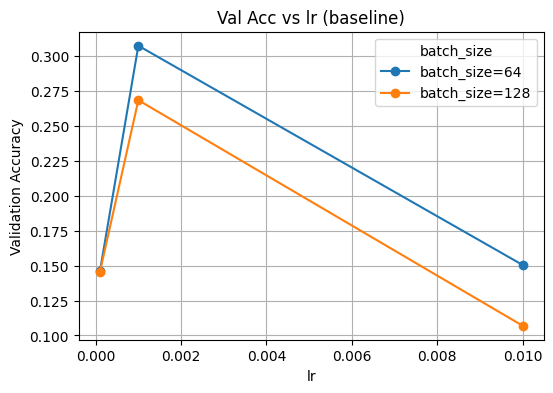

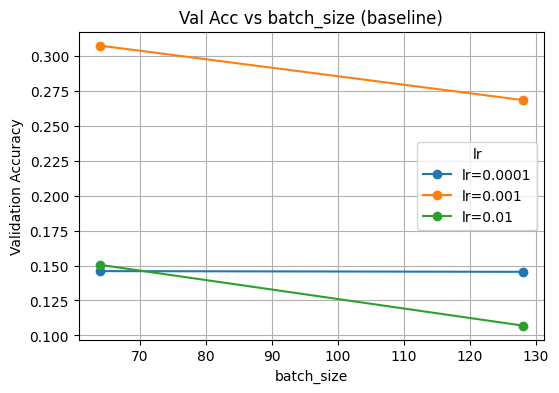

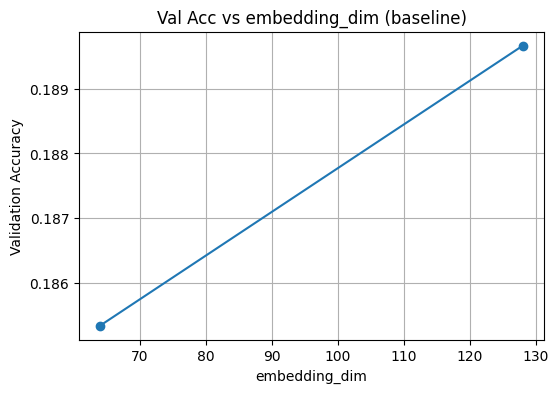

In [139]:
# 8) HP-effect plots (pure matplotlib)
plot_hp_effect(df_search_mnet, 'lr',         group='batch_size')
plot_hp_effect(df_search_mnet, 'batch_size', group='lr')
plot_hp_effect(df_search_mnet, 'embedding_dim')


In [140]:
# 9) Retrain on best MobileNetV2 config
best_mnet = df_search_mnet.iloc[0]
print("Best MobileNetV2 config:", best_mnet.to_dict())

model_mnet_best = MobileNetV2Emb(embedding_dim=int(best_mnet.embedding_dim)).to(device)
tlb = DataLoader(train_ds, batch_size=int(best_mnet.batch_size), shuffle=True,  num_workers=4)
vlb = DataLoader(val_ds,   batch_size=int(best_mnet.batch_size), shuffle=False, num_workers=4)
optb = optim.Adam(model_mnet_best.parameters(), lr=float(best_mnet.lr))

history_mnet_best = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for epoch in range(1,26):
    tl, ta = train_one_epoch(model_mnet_best, tlb, optb, criterion)
    vl, va = eval_one_epoch(model_mnet_best, vlb, criterion)
    history_mnet_best['train_loss'].append(tl)
    history_mnet_best['train_acc'].append(ta)
    history_mnet_best['val_loss'].append(vl)
    history_mnet_best['val_acc'].append(va)
    print(f"[MobileNetV2 Best] Epoch {epoch}/25 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


Best MobileNetV2 config: {'lr': 0.001, 'batch_size': 64.0, 'embedding_dim': 128.0, 'val_acc': 0.321}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[MobileNetV2 Best] Epoch 1/25 — Train L=2.8715 A=0.1275 | Val L=2.7618 A=0.1960
[MobileNetV2 Best] Epoch 2/25 — Train L=2.5453 A=0.2227 | Val L=2.4892 A=0.2610
[MobileNetV2 Best] Epoch 3/25 — Train L=2.3662 A=0.2753 | Val L=2.3227 A=0.2970
[MobileNetV2 Best] Epoch 4/25 — Train L=2.2476 A=0.3127 | Val L=2.2056 A=0.3360
[MobileNetV2 Best] Epoch 5/25 — Train L=2.1442 A=0.3432 | Val L=2.1877 A=0.3610
[MobileNetV2 Best] Epoch 6/25 — Train L=2.0692 A=0.3642 | Val L=2.0817 A=0.3610
[MobileNetV2 Best] Epoch 7/25 — Train L=1.9858 A=0.3943 | Val L=1.9440 A=0.4100
[MobileNetV2 Best] Epoch 8/25 — Train L=1.8894 A=0.4212 | Val L=1.9459 A=0.4130
[MobileNetV2 Best] Epoch 9/25 — Train L=1.8014 A=0.4511 | Val L=1.8570 A=0.4430
[MobileNetV2 Best] Epoch 10/25 — Train L=1.7136 A=0.4717 | Val L=1.7307 A=0.4690
[MobileNetV2 Best] Epoch 11/25 — Train L=1.6543 A=0.4949 | Val L=1.6680 A=0.4950
[MobileNetV2 Best] Epoch 12/25 — Train L=1.5867 A=0.5128 | Val L=1.7485 A=0.4590
[MobileNetV2 Best] Epoch 13/25 — Trai

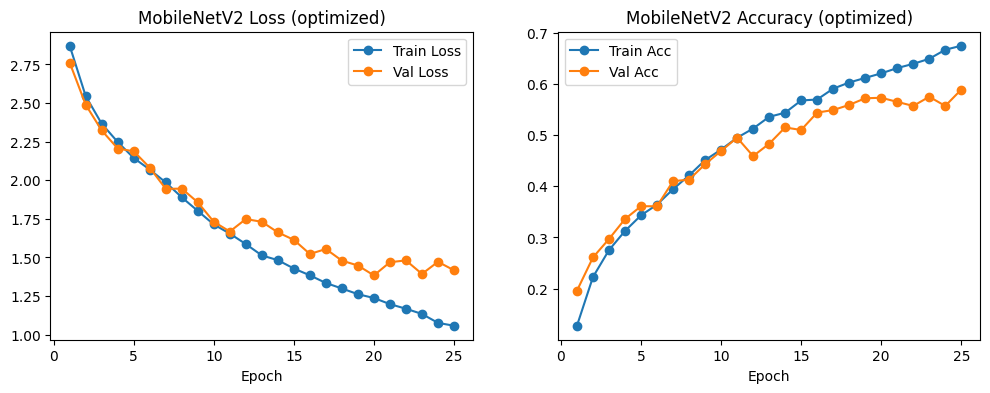

In [141]:
# 10) Optimized train/val curves (MobileNetV2)
epsb = range(1, len(history_mnet_best['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epsb, history_mnet_best['train_loss'], marker='o', label='Train Loss')
plt.plot(epsb, history_mnet_best['val_loss'],   marker='o', label='Val Loss')
plt.title('MobileNetV2 Loss (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epsb, history_mnet_best['train_acc'], marker='o', label='Train Acc')
plt.plot(epsb, history_mnet_best['val_acc'],   marker='o', label='Val Acc')
plt.title('MobileNetV2 Accuracy (optimized)'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [142]:
# 11) Final optimized metrics for MobileNetV2
best_contribs_mnet = compute_design_contributions(model_mnet_best)
df_mnet.loc[len(df_mnet)] = {
    'model':    'mobilenet_v2',
    'stage':    'optimized',
    'val_acc':  history_mnet_best['val_acc'][-1],
    'val_loss': history_mnet_best['val_loss'][-1],
    **best_contribs_mnet
}
df_mnet


,model,stage,val_acc,val_loss,#params
0,mobilenet_v2,initial,0.567,1.449190,2390420
1,mobilenet_v2,optimized,0.589,1.416807,2390420


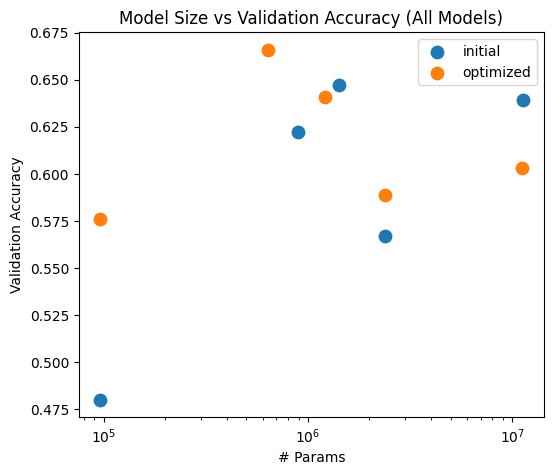

In [143]:
# 12) Combined trade-off scatter (All models)
df_all = pd.concat([df_baseline, df_medium, df_target, df_res, df_mnet], ignore_index=True)
plt.figure(figsize=(6,5))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage)
plt.xscale('log'); plt.xlabel('# Params'); plt.ylabel('Validation Accuracy')
plt.title('Model Size vs Validation Accuracy (All Models)'); plt.legend(); plt.show()


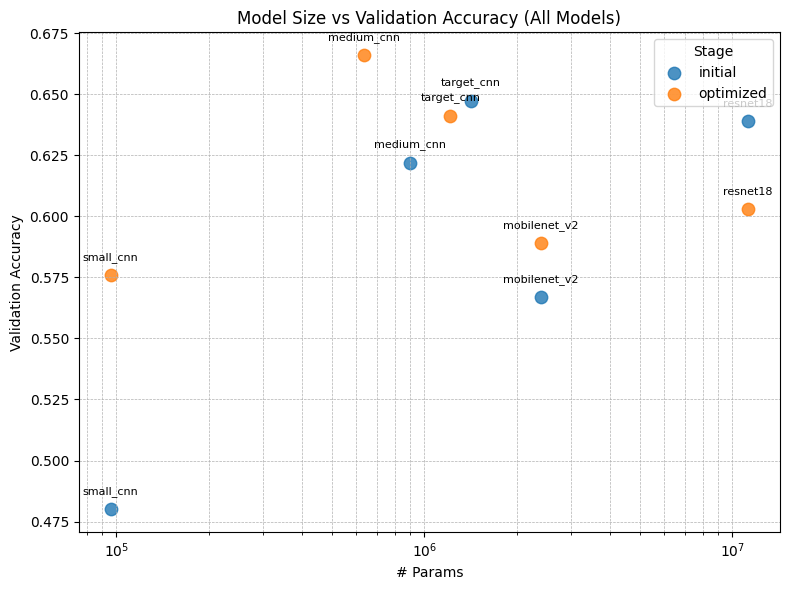

Best performing model: medium_cnn (optimized) with val_acc = 0.6660


In [145]:
# 12) Combined trade-off scatter (All models) with annotations and best performer
df_all = pd.concat([df_baseline, df_medium, df_target, df_res, df_mnet], ignore_index=True)

plt.figure(figsize=(8,6))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage, alpha=0.8)

for _, row in df_all.iterrows():
    x, y, name = row['#params'], row['val_acc'], row['model']
    plt.text(x, y + 0.005, name, fontsize=8, ha='center', va='bottom')

plt.xscale('log')
plt.xlabel('# Params')
plt.ylabel('Validation Accuracy')
plt.title('Model Size vs Validation Accuracy (All Models)')
plt.legend(title='Stage')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Identify and print the best-performing model
best_idx = df_all['val_acc'].idxmax()
best_row = df_all.loc[best_idx]
print(f"Best performing model: {best_row['model']} ({best_row['stage']}) with val_acc = {best_row['val_acc']:.4f}")


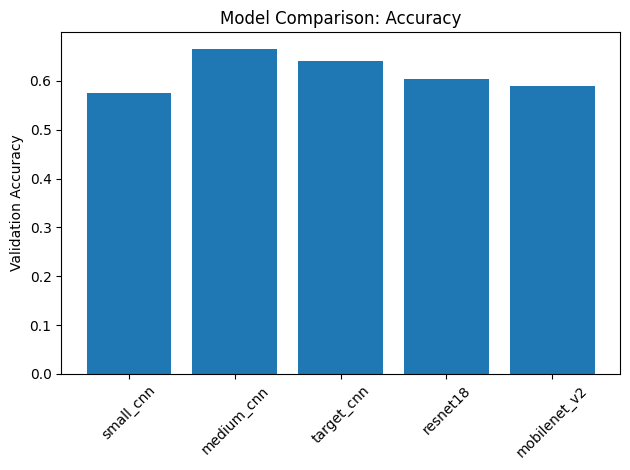

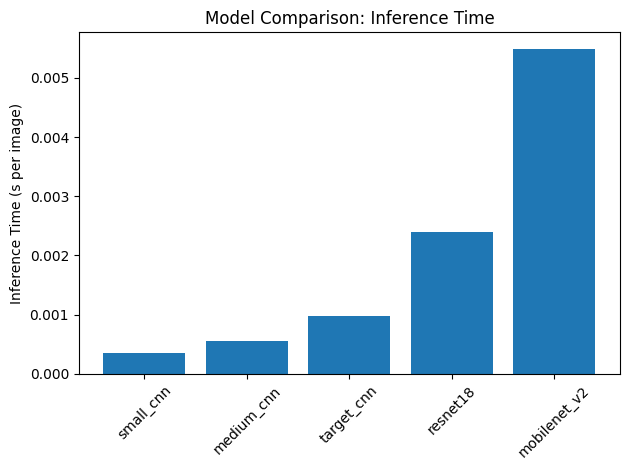

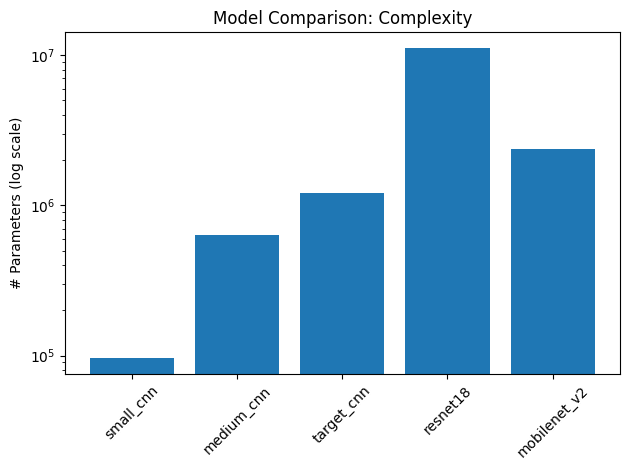

In [146]:
# Comparison of all models: Accuracy, Inference Time, Complexity
import time, torch
import matplotlib.pyplot as plt
import pandas as pd

# 1) Gather models
models = {
    'small_cnn':    model_best,
    'medium_cnn':   model_med_best,
    'target_cnn':   model_tgt_best,
    'resnet18':     model_res_best,
    'mobilenet_v2': model_mnet_best
}

# 2) Warm-up
dummy = torch.randn(1,3,64,64).to(device)
with torch.no_grad():
    for m in models.values():
        for _ in range(10):
            m(dummy)

# 3) Timing (100 inferences each)
times = {}
for name, m in models.items():
    if device.type=='cuda': torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(100):
            m(dummy)
    if device.type=='cuda': torch.cuda.synchronize()
    times[name] = (time.time() - t0) / 100

# 4) Build comparison DataFrame
df_opt = df_all[df_all['stage']=='optimized'].set_index('model')
rows = []
for name in models:
    rows.append({
        'model':          name,
        'val_acc':        df_opt.loc[name,'val_acc'],
        '#params':        df_opt.loc[name,'#params'],
        'inference_time': times[name]
    })
df_comp = pd.DataFrame(rows)

# 5a) Accuracy
plt.figure()
plt.bar(df_comp['model'], df_comp['val_acc'])
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison: Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5b) Inference Time
plt.figure()
plt.bar(df_comp['model'], df_comp['inference_time'])
plt.ylabel('Inference Time (s per image)')
plt.title('Model Comparison: Inference Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5c) Complexity (#params)
plt.figure()
plt.bar(df_comp['model'], df_comp['#params'])
plt.yscale('log')
plt.ylabel('# Parameters (log scale)')
plt.title('Model Comparison: Complexity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


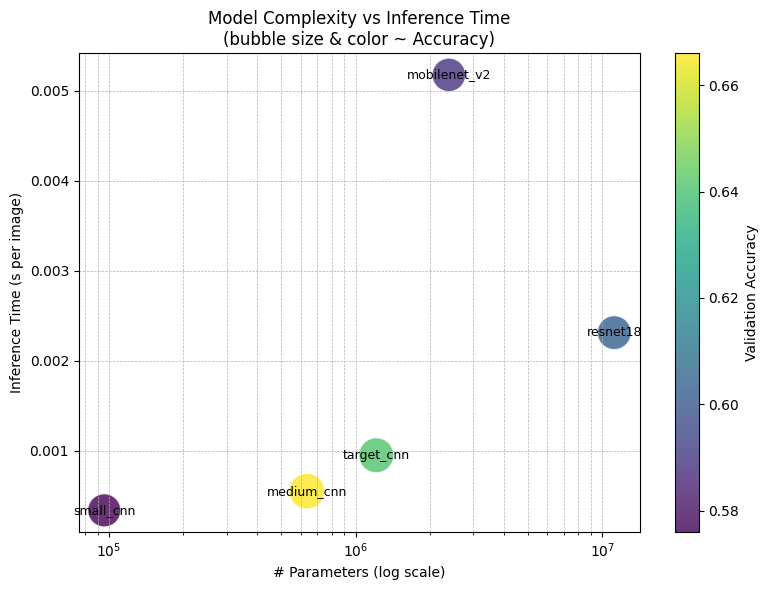

In [149]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

# 1) Collect optimized model instances
models = {
    'small_cnn':    model_best,
    'medium_cnn':   model_med_best,
    'target_cnn':   model_tgt_best,
    'resnet18':     model_res_best,
    'mobilenet_v2': model_mnet_best
}

# 2) Warm-up (10 passes each)
dummy = torch.randn(1,3,64,64).to(device)
with torch.no_grad():
    for m in models.values():
        for _ in range(10):
            m(dummy)

# 3) Measure inference time (100 runs)
times = {}
for name, m in models.items():
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(100):
            m(dummy)
    if device.type == 'cuda': torch.cuda.synchronize()
    times[name] = (time.time() - t0) / 100

# 4) Build comparison DataFrame
df_opt = df_all[df_all['stage']=='optimized'].set_index('model')
rows = []
for name in models:
    rows.append({
        'model':          name,
        'val_acc':        df_opt.loc[name,'val_acc'],
        '#params':        df_opt.loc[name,'#params'],
        'inference_time': times[name]
    })
df_comp = pd.DataFrame(rows)

# 5) Bubble chart
fig, ax = plt.subplots(figsize=(8,6))
sizes = df_comp['val_acc'] * 1000  # scale for visibility

sc = ax.scatter(
    df_comp['#params'],
    df_comp['inference_time'],
    s=sizes,
    c=df_comp['val_acc'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='w'
)

for _, row in df_comp.iterrows():
    ax.text(row['#params'], row['inference_time'], row['model'],
            fontsize=9, ha='center', va='center')

ax.set_xscale('log')
ax.set_xlabel('# Parameters (log scale)')
ax.set_ylabel('Inference Time (s per image)')
ax.set_title('Model Complexity vs Inference Time\n(bubble size & color ~ Accuracy)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Validation Accuracy')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


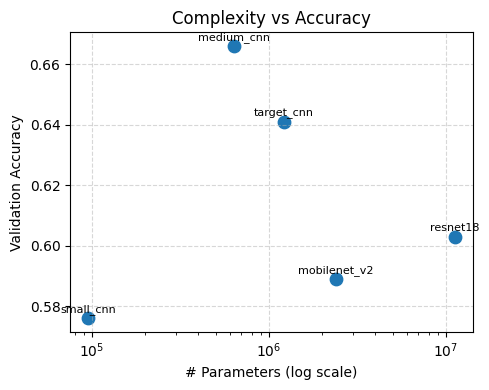

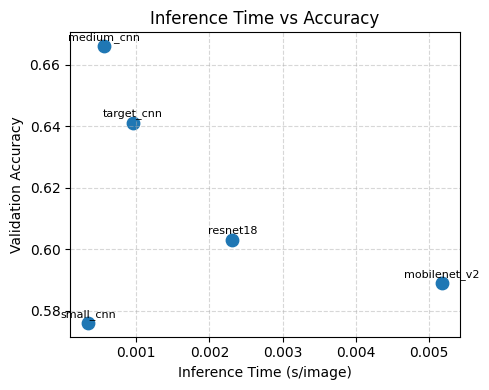

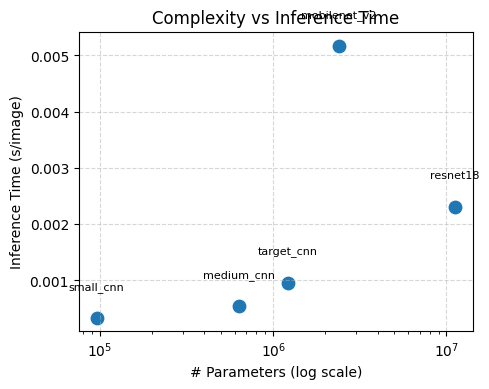

In [150]:
# Pairwise scatter plots: Complexity vs Accuracy, Time vs Accuracy, Complexity vs Time

# 1) Complexity vs Accuracy
plt.figure(figsize=(5,4))
plt.scatter(df_comp['#params'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['val_acc'] + 0.002, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Validation Accuracy')
plt.title('Complexity vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2) Inference Time vs Accuracy
plt.figure(figsize=(5,4))
plt.scatter(df_comp['inference_time'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['inference_time'], r['val_acc'] + 0.002, r['model'], fontsize=8, ha='center')
plt.xlabel('Inference Time (s/image)')
plt.ylabel('Validation Accuracy')
plt.title('Inference Time vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3) Complexity vs Inference Time
plt.figure(figsize=(5,4))
plt.scatter(df_comp['#params'], df_comp['inference_time'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['inference_time'] + 0.0005, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Inference Time (s/image)')
plt.title('Complexity vs Inference Time')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


          model  val_acc   #params  inference_time
0     small_cnn    0.576     95828        0.000341
1    medium_cnn    0.666    635220        0.000554
2    target_cnn    0.641   1214100        0.000952
3      resnet18    0.603  11193588        0.002314
4  mobilenet_v2    0.589   2390420        0.005176


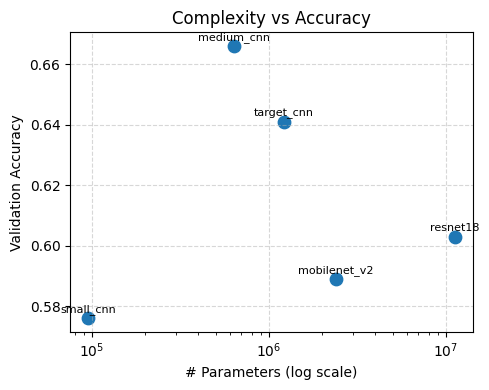

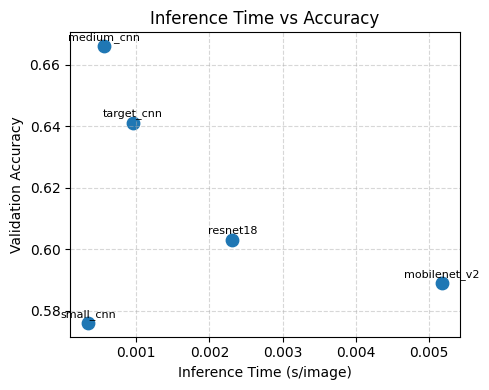

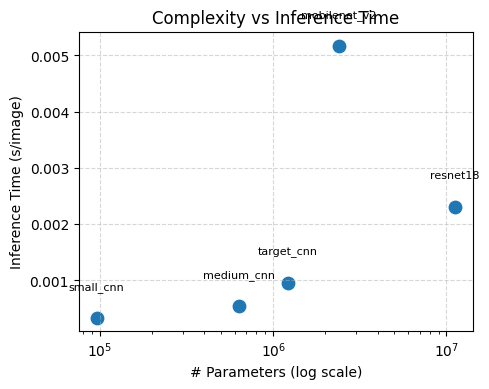

In [151]:
# 0) Print the comparison table
print(df_comp)

# 1) Complexity vs Accuracy
plt.figure(figsize=(5,4))
plt.scatter(df_comp['#params'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['val_acc'] + 0.002, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Validation Accuracy')
plt.title('Complexity vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2) Inference Time vs Accuracy
plt.figure(figsize=(5,4))
plt.scatter(df_comp['inference_time'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['inference_time'], r['val_acc'] + 0.002, r['model'], fontsize=8, ha='center')
plt.xlabel('Inference Time (s/image)')
plt.ylabel('Validation Accuracy')
plt.title('Inference Time vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3) Complexity vs Inference Time
plt.figure(figsize=(5,4))
plt.scatter(df_comp['#params'], df_comp['inference_time'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['inference_time'] + 0.0005, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Inference Time (s/image)')
plt.title('Complexity vs Inference Time')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# 3) Baseline model: DenseNet121
from torchvision.models import densenet121
import torch.nn as nn

class DenseNet121Emb(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=20):
        super().__init__()
        backbone = densenet121(pretrained=False)
        in_feats = backbone.classifier.in_features
        backbone.classifier = nn.Identity()    # drop original head
        self.backbone   = backbone
        self.embedding  = nn.Linear(in_feats, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)
    def forward(self, x):
        x = self.backbone(x)      # features -> adaptive pool -> flatten
        x = self.embedding(x)
        return self.classifier(x)

model_den = DenseNet121Emb(embedding_dim=128).to(device)
print(model_den)


DenseNet121Emb(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# 4) One-shot training & evaluation on DenseNet121
optimizer = optim.Adam(model_den.parameters(), lr=1e-3)
history_den = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1,16):
    tl, ta = train_one_epoch(model_den, train_loader, optimizer, criterion)
    vl, va = eval_one_epoch(model_den,   val_loader,   criterion)
    history_den['train_loss'].append(tl)
    history_den['train_acc'].append(ta)
    history_den['val_loss'].append(vl)
    history_den['val_acc'].append(va)
    print(f"[DenseNet121] Epoch {epoch}/15 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


[DenseNet121] Epoch 1/15 — Train L=2.3528 A=0.2854 | Val L=2.1232 A=0.3580


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ff0ab85440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x79ff0ab85440>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
^    ^self._shutdown_workers()^^^^
^  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
^
      File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():
      assert self._parent_pid == os.getpid(), 'can only test a child process' 
       ^^ ^^ ^^ ^ ^^ ^ ^^  
^  File "/us

[DenseNet121] Epoch 2/15 — Train L=1.8955 A=0.4173 | Val L=1.7466 A=0.4640
[DenseNet121] Epoch 3/15 — Train L=1.6838 A=0.4841 | Val L=1.6048 A=0.5110
[DenseNet121] Epoch 4/15 — Train L=1.5339 A=0.5284 | Val L=1.6524 A=0.5240
[DenseNet121] Epoch 5/15 — Train L=1.4086 A=0.5706 | Val L=1.5552 A=0.5380
[DenseNet121] Epoch 6/15 — Train L=1.3222 A=0.5924 | Val L=1.3944 A=0.5920
[DenseNet121] Epoch 7/15 — Train L=1.2325 A=0.6214 | Val L=1.2989 A=0.6070
[DenseNet121] Epoch 8/15 — Train L=1.1671 A=0.6383 | Val L=1.3272 A=0.6020
[DenseNet121] Epoch 9/15 — Train L=1.0877 A=0.6612 | Val L=1.2522 A=0.6300
[DenseNet121] Epoch 10/15 — Train L=1.0348 A=0.6813 | Val L=1.2065 A=0.6230
[DenseNet121] Epoch 11/15 — Train L=0.9664 A=0.6958 | Val L=1.2213 A=0.6370
[DenseNet121] Epoch 12/15 — Train L=0.9134 A=0.7138 | Val L=1.1896 A=0.6420
[DenseNet121] Epoch 13/15 — Train L=0.8643 A=0.7281 | Val L=1.2034 A=0.6480
[DenseNet121] Epoch 14/15 — Train L=0.7842 A=0.7497 | Val L=1.1694 A=0.6530
[DenseNet121] Epoch 

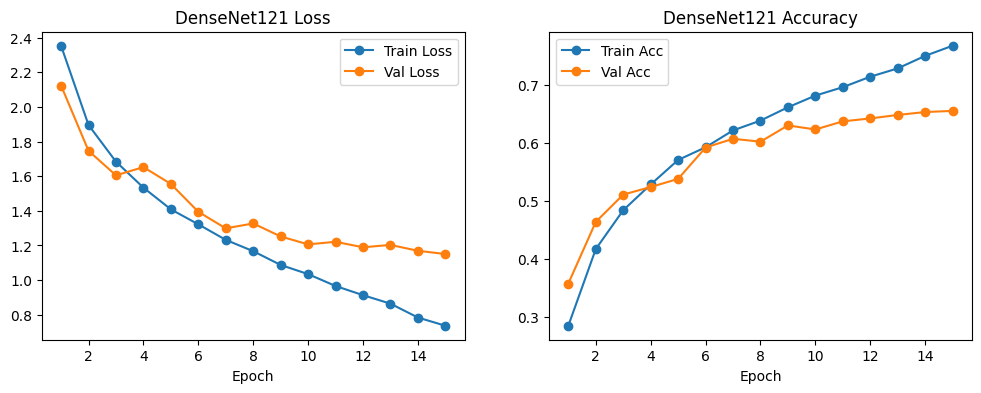

In [155]:
# 5) Train/validation loss & accuracy curves (dynamic)
eps = range(1, len(history_den['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(eps, history_den['train_loss'], marker='o', label='Train Loss')
plt.plot(eps, history_den['val_loss'],   marker='o', label='Val Loss')
plt.title('DenseNet121 Loss'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(eps, history_den['train_acc'], marker='o', label='Train Acc')
plt.plot(eps, history_den['val_acc'],   marker='o', label='Val Acc')
plt.title('DenseNet121 Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [156]:
# 6) Initial metrics & design contributions
init_contribs_den = compute_design_contributions(model_den)
df_den = pd.DataFrame([{
    'model':    'densenet121',
    'stage':    'initial',
    'val_acc':  history_den['val_acc'][-1],
    'val_loss': history_den['val_loss'][-1],
    **init_contribs_den
}])
df_den


,model,stage,val_acc,val_loss,#params
0,densenet121,initial,0.655,1.150732,7087636


In [157]:
# 7) Hyperparameter search (lr, batch_size, embedding_dim)
from itertools import product
search_den = []
for lr, bs, emb in product([1e-4,1e-3,1e-2], [64,128], [64,128]):
    m   = DenseNet121Emb(embedding_dim=emb).to(device)
    tl  = DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=4)
    vl  = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4)
    opt = optim.Adam(m.parameters(), lr=lr)
    for _ in range(5):
        train_one_epoch(m, tl, opt, criterion)
    _, va = eval_one_epoch(m, vl, criterion)
    search_den.append({
        'lr':lr, 'batch_size':bs, 'embedding_dim':emb, 'val_acc':va
    })

df_search_den = pd.DataFrame(search_den).sort_values('val_acc', ascending=False)
df_search_den.head()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


,lr,batch_size,embedding_dim,val_acc
4,0.0010,64,64,0.578
5,0.0010,64,128,0.550
6,0.0010,128,64,0.529
7,0.0010,128,128,0.523
1,0.0001,64,128,0.515


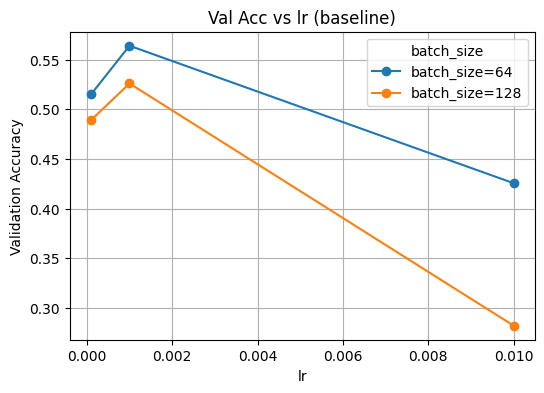

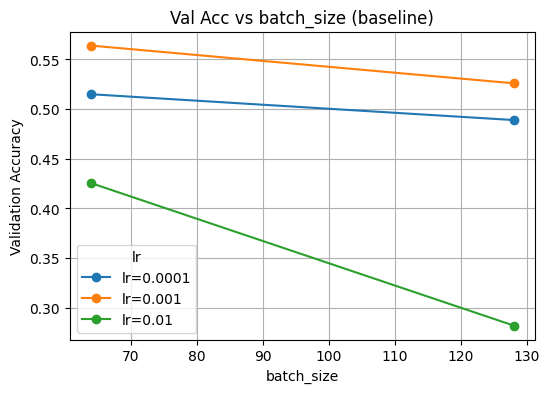

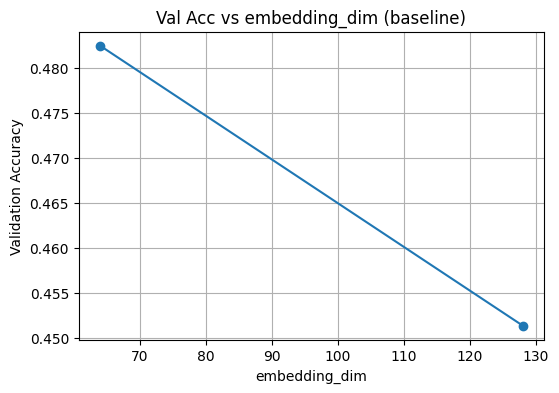

In [158]:
# 8) HP-effect plots (pure matplotlib)
plot_hp_effect(df_search_den, 'lr',         group='batch_size')
plot_hp_effect(df_search_den, 'batch_size', group='lr')
plot_hp_effect(df_search_den, 'embedding_dim')


In [159]:
# 9) Retrain on best DenseNet121 config
best_den = df_search_den.iloc[0]
print("Best DenseNet121 config:", best_den.to_dict())

model_den_best = DenseNet121Emb(embedding_dim=int(best_den.embedding_dim)).to(device)
tlb = DataLoader(train_ds, batch_size=int(best_den.batch_size), shuffle=True,  num_workers=4)
vlb = DataLoader(val_ds,   batch_size=int(best_den.batch_size), shuffle=False, num_workers=4)
optb = optim.Adam(model_den_best.parameters(), lr=float(best_den.lr))

history_den_best = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for epoch in range(1,6):
    tl, ta = train_one_epoch(model_den_best, tlb, optb, criterion)
    vl, va = eval_one_epoch(model_den_best, vlb, criterion)
    history_den_best['train_loss'].append(tl)
    history_den_best['train_acc'].append(ta)
    history_den_best['val_loss'].append(vl)
    history_den_best['val_acc'].append(va)
    print(f"[DenseNet121 Best] Epoch {epoch}/5 — Train L={tl:.4f} A={ta:.4f} | Val L={vl:.4f} A={va:.4f}")


Best DenseNet121 config: {'lr': 0.001, 'batch_size': 64.0, 'embedding_dim': 64.0, 'val_acc': 0.578}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[DenseNet121 Best] Epoch 1/5 — Train L=2.3509 A=0.2869 | Val L=2.0403 A=0.3780
[DenseNet121 Best] Epoch 2/5 — Train L=1.8426 A=0.4321 | Val L=1.8728 A=0.4380
[DenseNet121 Best] Epoch 3/5 — Train L=1.6445 A=0.4962 | Val L=1.6787 A=0.5130
[DenseNet121 Best] Epoch 4/5 — Train L=1.4647 A=0.5472 | Val L=1.5361 A=0.5280
[DenseNet121 Best] Epoch 5/5 — Train L=1.3616 A=0.5786 | Val L=1.4349 A=0.5770


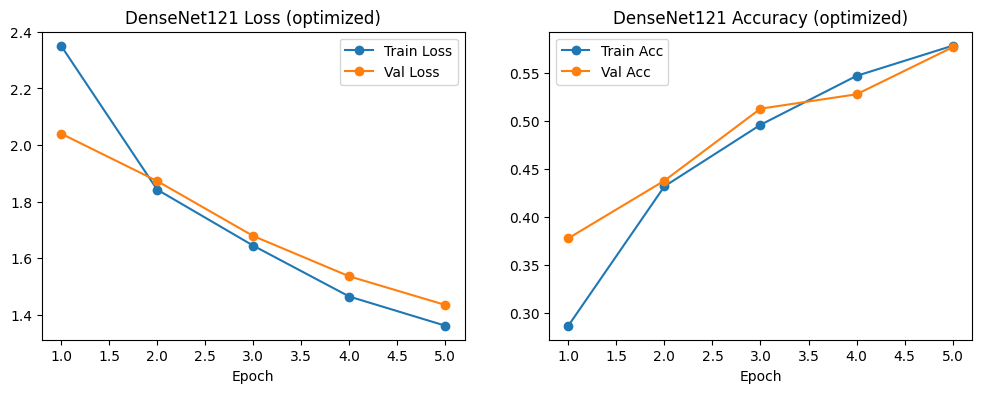

In [160]:
# 10) Optimized train/val curves (DenseNet121)
epsb = range(1, len(history_den_best['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epsb, history_den_best['train_loss'], marker='o', label='Train Loss')
plt.plot(epsb, history_den_best['val_loss'],   marker='o', label='Val Loss')
plt.title('DenseNet121 Loss (optimized)'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epsb, history_den_best['train_acc'], marker='o', label='Train Acc')
plt.plot(epsb, history_den_best['val_acc'],   marker='o', label='Val Acc')
plt.title('DenseNet121 Accuracy (optimized)'); plt.xlabel('Epoch'); plt.legend()
plt.show()


In [161]:
# 11) Final optimized metrics for DenseNet121
best_contribs_den = compute_design_contributions(model_den_best)
df_den.loc[len(df_den)] = {
    'model':    'densenet121',
    'stage':    'optimized',
    'val_acc':  history_den_best['val_acc'][-1],
    'val_loss': history_den_best['val_loss'][-1],
    **best_contribs_den
}
df_den


,model,stage,val_acc,val_loss,#params
0,densenet121,initial,0.655,1.150732,7087636
1,densenet121,optimized,0.577,1.434913,7020756


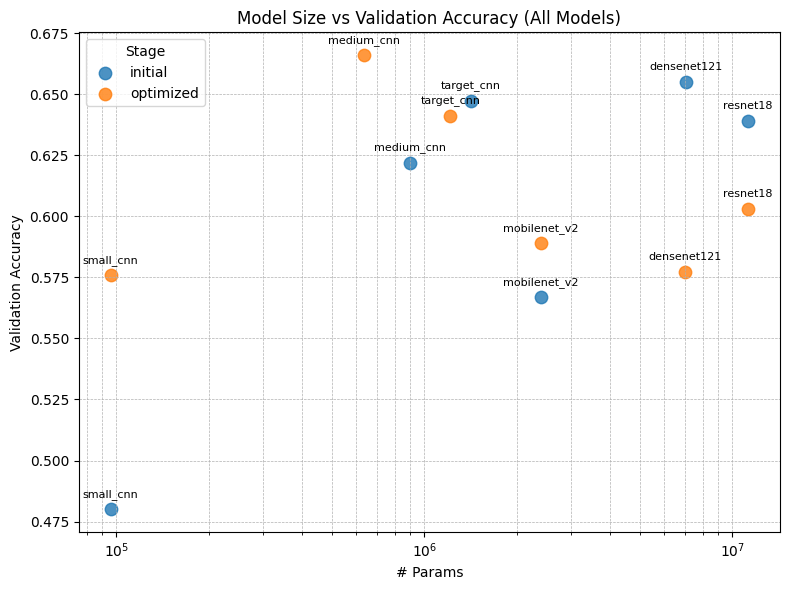

In [162]:
# 12) Combined trade-off scatter (All models)
df_all = pd.concat([df_baseline, df_medium, df_target, df_res, df_mnet, df_den], ignore_index=True)
plt.figure(figsize=(8,6))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage, alpha=0.8)
for _, row in df_all.iterrows():
    plt.text(row['#params'], row['val_acc'] + 0.005, row['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Params')
plt.ylabel('Validation Accuracy')
plt.title('Model Size vs Validation Accuracy (All Models)')
plt.legend(title='Stage')
plt.grid(True, which='both', ls='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [165]:
# Comparison table and 3D scatter: Complexity vs Inference Time vs Accuracy

import time
import torch
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# 1) Gather all optimized models
models = {
    'small_cnn':    model_best,
    'medium_cnn':   model_med_best,
    'target_cnn':   model_tgt_best,
    'resnet18':     model_res_best,
    'mobilenet_v2': model_mnet_best,
    'densenet121':  model_den_best
}

# 2) Warm-up
dummy = torch.randn(1, 3, 64, 64).to(device)
with torch.no_grad():
    for m in models.values():
        for _ in range(10):
            m(dummy)

# 3) Measure average inference time per image (100 runs)
times = {}
for name, m in models.items():
    if device.type == 'cuda': 
        torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for _ in range(100):
            m(dummy)
    if device.type == 'cuda': 
        torch.cuda.synchronize()
    times[name] = (time.time() - start) / 100

# 4) Build comparison DataFrame
df_opt = df_all[df_all['stage']=='optimized'].set_index('model')
rows = []
for name in models:
    rows.append({
        'model':          name,
        'val_acc':        df_opt.loc[name, 'val_acc'],
        '#params':        df_opt.loc[name, '#params'],
        'inference_time': times[name]
    })
df_comp = pd.DataFrame(rows)

# 5) Print the comparison values
print("Comparison of optimized models:")
print(df_comp.to_string(index=False))

# 6) 3D Scatter plot: Complexity vs Inference Time vs Accuracy
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for _, r in df_comp.iterrows():
    x = r['#params']
    y = r['inference_time']
    z = r['val_acc']
    ax.scatter(x, y, z, s=80)
    ax.text(x, y, z, r['model'], fontsize=8, ha='center', va='bottom')

ax.set_xscale('log')
ax.set_xlabel('# Parameters (log scale)')
ax.set_ylabel('Inference Time (s/image)')
ax.set_zlabel('Validation Accuracy')
ax.set_title('Model Complexity vs Inference Time vs Accuracy')
plt.tight_layout()
plt.show()


Comparison of optimized models:
       model  val_acc  #params  inference_time
   small_cnn    0.576    95828        0.000381
  medium_cnn    0.666   635220        0.000562
  target_cnn    0.641  1214100        0.000980
    resnet18    0.603 11193588        0.002330
mobilenet_v2    0.589  2390420        0.005291
 densenet121    0.577  7020756        0.016492


ValueError: Unknown projection '2d'

<Figure size 800x600 with 0 Axes>

          model  val_acc   #params  inference_time
0     small_cnn    0.576     95828        0.000354
1    medium_cnn    0.666    635220        0.000578
2    target_cnn    0.641   1214100        0.000963
3      resnet18    0.603  11193588        0.002469
4  mobilenet_v2    0.589   2390420        0.005376
5   densenet121    0.577   7020756        0.016243


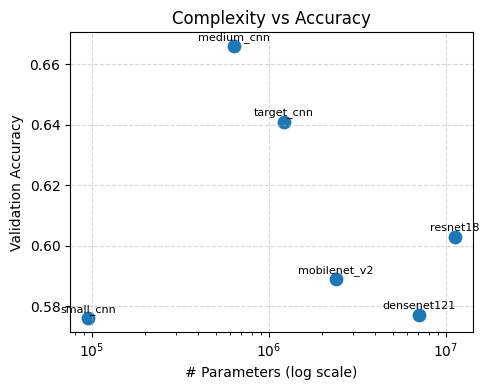

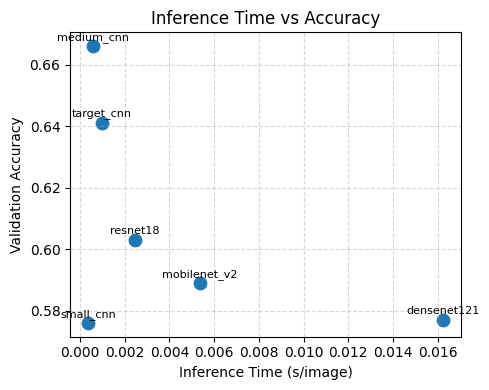

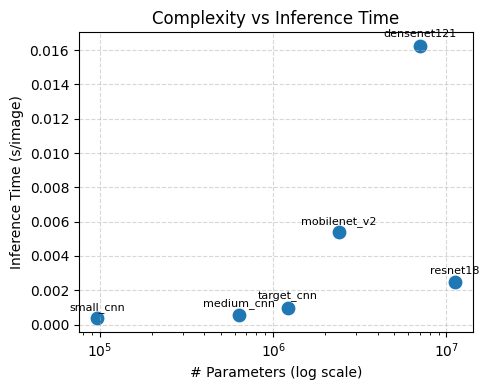

In [164]:
# Updated comparison including DenseNet121

import time, torch, matplotlib.pyplot as plt, pandas as pd
# 1) Gather all optimized models
models = {
    'small_cnn':    model_best,
    'medium_cnn':   model_med_best,
    'target_cnn':   model_tgt_best,
    'resnet18':     model_res_best,
    'mobilenet_v2': model_mnet_best,
    'densenet121':  model_den_best
}

# 2) Warm-up on dummy input
dummy = torch.randn(1,3,64,64).to(device)
with torch.no_grad():
    for m in models.values():
        for _ in range(10): m(dummy)

# 3) Measure inference time (100 runs per model)
times = {}
for name, m in models.items():
    if device.type=='cuda': torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(100): m(dummy)
    if device.type=='cuda': torch.cuda.synchronize()
    times[name] = (time.time() - t0) / 100

# 4) Build comparison DataFrame
df_opt = df_all[df_all['stage']=='optimized'].set_index('model')
rows = []
for name in models:
    rows.append({
        'model':          name,
        'val_acc':        df_opt.loc[name,'val_acc'],
        '#params':        df_opt.loc[name,'#params'],
        'inference_time': times[name]
    })
df_comp = pd.DataFrame(rows)

# 0) Print the comparison table
print(df_comp)

# 1) Complexity vs Accuracy
plt.figure(figsize=(5,4))
plt.scatter(df_comp['#params'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['val_acc'] + 0.002, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Validation Accuracy')
plt.title('Complexity vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2) Inference Time vs Accuracy
plt.figure(figsize=(5,4))
plt.scatter(df_comp['inference_time'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['inference_time'], r['val_acc'] + 0.002, r['model'], fontsize=8, ha='center')
plt.xlabel('Inference Time (s/image)')
plt.ylabel('Validation Accuracy')
plt.title('Inference Time vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3) Complexity vs Inference Time
plt.figure(figsize=(5,4))
plt.scatter(df_comp['#params'], df_comp['inference_time'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['inference_time'] + 0.0005, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Inference Time (s/image)')
plt.title('Complexity vs Inference Time')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [167]:
# ─── Save results to CSV ──────────────────────────────────────────────────────
df_all.to_csv('all_models_metrics.csv', index=False)
df_comp.to_csv('optimized_models_comparison.csv', index=False)
print("Saved full metrics to all_models_metrics.csv")
print("Saved optimized comparison to optimized_models_comparison.csv")

Saved full metrics to all_models_metrics.csv
Saved optimized comparison to optimized_models_comparison.csv


In [168]:
# Save all result DataFrames to CSV
dfs = {
    'small_cnn_results': df_baseline,
    'medium_cnn_results': df_medium,
    'target_cnn_results': df_target,
    'resnet18_results': df_res,
    'mobilenet_v2_results': df_mnet,
    'densenet121_results': df_den,
    'all_models_results': df_all,
    'comparison_results': df_comp
}

for name, df in dfs.items():
    filename = f'{name}.csv'
    df.to_csv(filename, index=False)
    print(f"Saved {filename}")


Saved small_cnn_results.csv
Saved medium_cnn_results.csv
Saved target_cnn_results.csv
Saved resnet18_results.csv
Saved mobilenet_v2_results.csv
Saved densenet121_results.csv
Saved all_models_results.csv
Saved comparison_results.csv


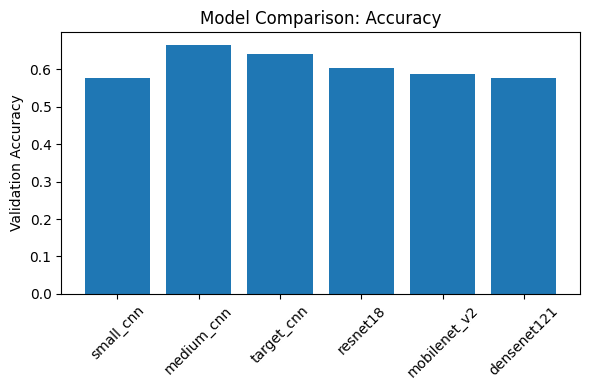

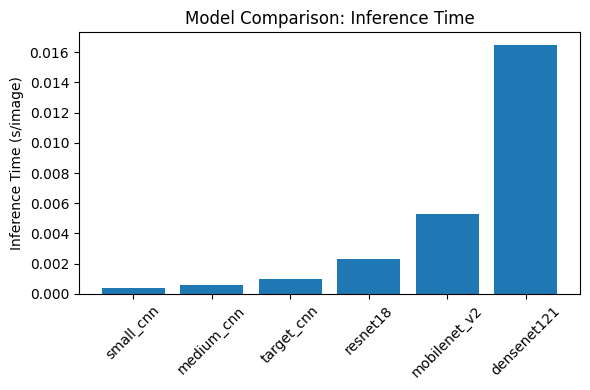

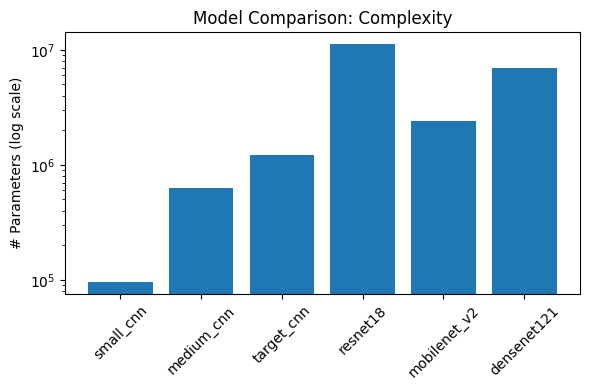

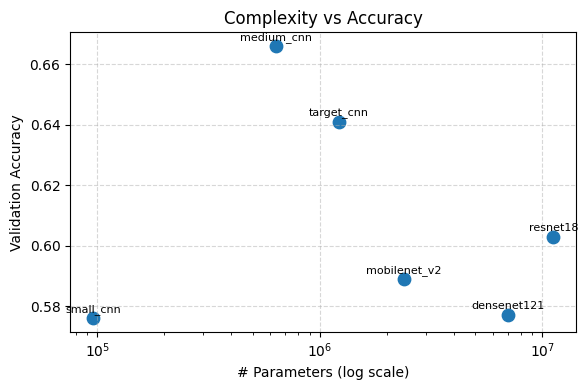

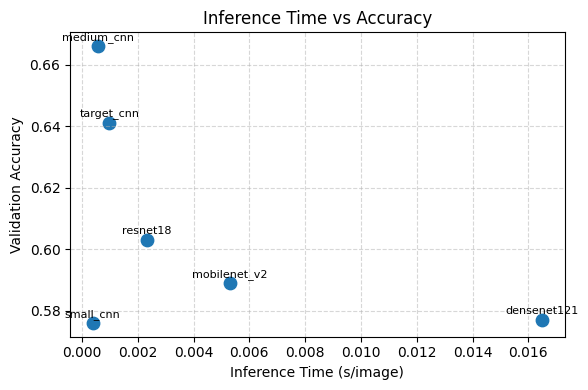

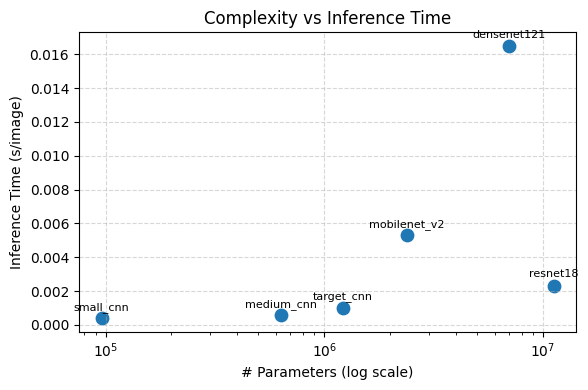

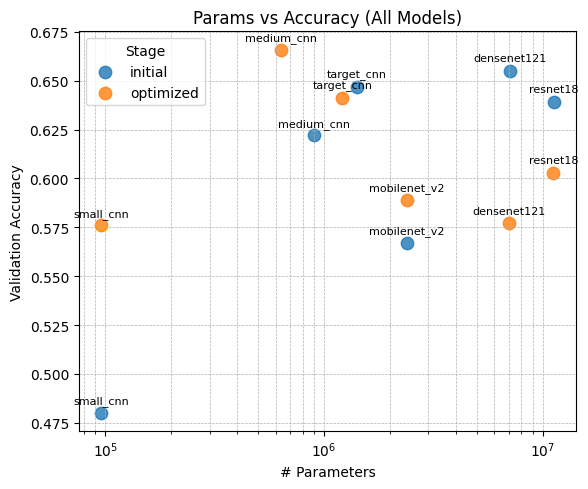

In [169]:
import matplotlib.pyplot as plt

# Assumes df_comp and df_all are already defined

# 1) Bar charts

# Accuracy
plt.figure(figsize=(6,4))
plt.bar(df_comp['model'], df_comp['val_acc'])
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison: Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Inference Time
plt.figure(figsize=(6,4))
plt.bar(df_comp['model'], df_comp['inference_time'])
plt.ylabel('Inference Time (s/image)')
plt.title('Model Comparison: Inference Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Complexity (# params, log scale)
plt.figure(figsize=(6,4))
plt.bar(df_comp['model'], df_comp['#params'])
plt.yscale('log')
plt.ylabel('# Parameters (log scale)')
plt.title('Model Comparison: Complexity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2) 2D Scatter plots

# Complexity vs Accuracy
plt.figure(figsize=(6,4))
plt.scatter(df_comp['#params'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['val_acc']+0.002, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Validation Accuracy')
plt.title('Complexity vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Inference Time vs Accuracy
plt.figure(figsize=(6,4))
plt.scatter(df_comp['inference_time'], df_comp['val_acc'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['inference_time'], r['val_acc']+0.002, r['model'], fontsize=8, ha='center')
plt.xlabel('Inference Time (s/image)')
plt.ylabel('Validation Accuracy')
plt.title('Inference Time vs Accuracy')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Complexity vs Inference Time
plt.figure(figsize=(6,4))
plt.scatter(df_comp['#params'], df_comp['inference_time'], s=80)
for _, r in df_comp.iterrows():
    plt.text(r['#params'], r['inference_time']+0.0005, r['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters (log scale)')
plt.ylabel('Inference Time (s/image)')
plt.title('Complexity vs Inference Time')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 3) Combined trade-off scatter (annotated)
plt.figure(figsize=(6,5))
for stage, grp in df_all.groupby('stage'):
    plt.scatter(grp['#params'], grp['val_acc'], s=80, label=stage, alpha=0.8)
for _, row in df_all.iterrows():
    plt.text(row['#params'], row['val_acc']+0.005, row['model'], fontsize=8, ha='center')
plt.xscale('log')
plt.xlabel('# Parameters')
plt.ylabel('Validation Accuracy')
plt.title('Params vs Accuracy (All Models)')
plt.legend(title='Stage')
plt.grid(True, which='both', ls='--', linewidth=0.5)
plt.tight_layout()
plt.show()
